# Power Spectrum Analysis with NaMaster

Auto and cross power spectra for:
- **Proper motion map** (star, spin-1)
- **Stellar density map** (spin-0)
- **m10 / scanning strategy map** from Quaia (spin-0)

NaMaster handles ell >= 2. Healpy is used for ell = 1.  
Variance is estimated via Monte Carlo simulation of Gaussian random fields.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pymaster as nmt
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.io import fits
from scipy.stats import chi2
import astropy.table as at

import matplotlib as mpl


plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'text.usetex': False,
})


plt.rcParams.update({
    'mathtext.fontset': 'cm',       # Computer Modern
    'mathtext.default': 'regular',
})



## Parameters

In [30]:
nside = 64
npix  = hp.nside2npix(nside)
nbin  = 1           # multipoles per band-power bin
lmax_hp = 3 * nside - 1  # healpy lmax for map2alm
N_SIMS = 500        # number of Monte Carlo realisations for variance
APOD_SCALE = 10.0   # apodisation scale in degrees
APOD_TYPE  = 'C1'



In [31]:
from sbi_hpm.geometry import SkyFunction
from sbi_hpm.pixelization import Pixelize
from sbi_hpm.power_spectrum_analysis import (
    make_bins, make_spin1_field, make_spin0_field,
    apodize_mask, compute_power_spectrum,
    estimate_noise_covariance, evaluate_cross_spectrum,
)
from sbi_hpm.plotting import plot_power_spectrum, plot_snr_per_ell
skyfunc = SkyFunction(nside)
pixelize = Pixelize(nside)

## Helper functions

In [32]:
def sum_in_pixels(theta, phi, nside, weights=None):
    """Bin objects into HEALPix pixels and return the sum of weights (or counts)."""
    pixel_indices = hp.ang2pix(nside, theta, phi)
    result = np.zeros(hp.nside2npix(nside))
    if weights is None:
        weights = np.ones(len(theta))
    np.add.at(result, pixel_indices, weights)
    return result


def weighted_mean_in_pixels(theta, phi, nside, values, weights):
    """Compute the inverse-variance-weighted mean of `values` per pixel."""
    pixel_indices = hp.ang2pix(nside, theta, phi)
    npix_local    = hp.nside2npix(nside)
    sum_vw = np.zeros(npix_local)
    sum_w  = np.zeros(npix_local)
    np.add.at(sum_vw, pixel_indices, values * weights)
    np.add.at(sum_w,  pixel_indices, weights)
    with np.errstate(invalid='ignore', divide='ignore'):
        mean = np.where(sum_w > 0, sum_vw / sum_w, 0.0)
    return mean, sum_w

def _extract_ell1_alm(alm, lmax):
    """Return a copy of alm with all coefficients zeroed except ell=1 (m=0,1)."""
    alm_l1 = np.zeros_like(alm)
    for m in range(2):   # ell=1 has m = 0, 1
        idx = hp.Alm.getidx(lmax, 1, m)
        alm_l1[idx] = alm[idx]
    return alm_l1

def cl_at_ell1_spin0(map1, map2, mask, lmax):
    """
    Estimate the pseudo-Cl cross-spectrum at ell=1 for two spin-0 maps
    using healpy.  The maps are multiplied by the mask before the transform.
    Returns a scalar C_l=1.
    """
    m1 = map1 * mask
    m2 = map2 * mask
    alm1 = hp.map2alm(m1, lmax=lmax)
    alm2 = hp.map2alm(m2, lmax=lmax)
    cl = hp.alm2cl(alm1, alm2, lmax=lmax)   # length 2: [ell=0, ell=1]
    f_sky = np.mean(mask**2)
    return cl[1] / f_sky          # crude pseudo-Cl correction


def cl_at_ell1_spin1_x_spin0(pm_ra, pm_dec, scalar_map, mask, lmax):
    """
    Estimate ell=1 pseudo-Cl between a spin-1 field (pm_ra, pm_dec)
    and a spin-0 field, using healpy map2alm_spin.
    Returns [C_ell1_E-scalar, C_ell1_B-scalar].
    """
    mQ = pm_ra  * mask
    mU = pm_dec * mask
    ms = scalar_map * mask

    alm_E, alm_B = hp.map2alm_spin([-mU, mQ], spin=1, lmax= lmax)
    alm_s        = hp.map2alm(ms, lmax=lmax)
    f_sky = np.mean(mask**2)


    alm_E1 = _extract_ell1_alm(alm_E, lmax)
    alm_B1 = _extract_ell1_alm(alm_B, lmax)
    alm_s1 = _extract_ell1_alm(alm_s, lmax)

    cl_Es = hp.alm2cl(alm_E1, alm_s1, lmax=lmax)
    cl_Bs = hp.alm2cl(alm_B1, alm_s1, lmax=lmax)
    return cl_Es[1] / f_sky, cl_Bs[1] / f_sky


def cl_at_ell1_spin1_auto(pm_ra, pm_dec, mask, lmax):
    """
    Estimate ell=1 pseudo-Cl for the auto-spectrum of a spin-1 field.
    Returns [C_ell1_EE, C_ell1_BB].
    """
    mQ = pm_ra  * mask
    mU = pm_dec * mask
    alm_E, alm_B = hp.map2alm_spin([-mU, mQ], spin=1, lmax=lmax)
    f_sky = np.mean(mask**2)

    alm_E1 = _extract_ell1_alm(alm_E, lmax)
    alm_B1 = _extract_ell1_alm(alm_B, lmax)

    cl_EE = hp.alm2cl(alm_E1,        lmax=lmax)
    cl_BB = hp.alm2cl(alm_B1,        lmax=lmax)
    return cl_EE[1] / f_sky, cl_BB[1] / f_sky

## Load data

In [33]:
# ── QSO / gaia data (used for scanning / m10 map) ──────────────────────────
quaia = fits.open('quaia_G20.0.fits')

gaia    = pd.read_csv('gaia_qso_edata_5_params.csv')

# table_quaia = at.Table.read(quaia)
# gaia = gaia[gaia['source_id'].isin(table_quaia['source_id'])]

scanning = pd.read_csv('gaia_scanning.csv')

# ── Faint stars ─────────────────────────────────────────────────────────────
star = pd.concat([
    pd.read_csv('gaia_faint_stars_90.csv'),
    pd.read_csv('gaia_faint_stars_180.csv'),
    pd.read_csv('gaia_faint_stars_270.csv'),
    pd.read_csv('gaia_faint_stars_360.csv'),
], ignore_index=True)

print(f'QSO rows : {len(gaia)}')
print(f'Star rows: {len(star)}')

QSO rows : 1215942
Star rows: 6465890


## Build maps
### Stellar proper motion + density maps

In [34]:
gaia_ra  = gaia['ra'].values
gaia_dec = gaia['dec'].values
gaia_pmra  = gaia['pmra'].values
gaia_pmdec = gaia['pmdec'].values

gaia_sig_pmra  = gaia['pmra_error'].values
gaia_sig_pmdec = gaia['pmdec_error'].values 
gaia_pm_corr    = gaia['pmra_pmdec_corr'].values

gaia_theta = np.radians(90 - gaia_dec)
gaia_phi   = np.radians(gaia_ra)

sig_pmra_gaia  = gaia['pmra_error'].values
sig_pmdec_gaia = gaia['pmdec_error'].values

# Inverse-variance weights
w_pmra_gaia  = np.where(sig_pmra_gaia  > 0, 1.0 / sig_pmra_gaia**2,  0)
w_pmdec_gaia = np.where(sig_pmdec_gaia > 0, 1.0 / sig_pmdec_gaia**2, 0)

gaia_pmra_wm = pixelize.calculate_weighted_means(gaia_theta, gaia_phi, gaia_pmra, gaia_sig_pmra) 
gaia_pmdec_wm = pixelize.calculate_weighted_means(gaia_theta, gaia_phi, gaia_pmdec, gaia_sig_pmdec) 
sw_ra  = pixelize.sum_in_pixels(gaia_theta, gaia_phi, weights=1 / sig_pmra_gaia**2)
sw_dec = pixelize.sum_in_pixels(gaia_theta, gaia_phi, weights=1 / sig_pmdec_gaia**2)
cinv_rd = pixelize.sum_in_pixels(gaia_theta, gaia_phi,
              weights=gaia_pm_corr / (gaia_sig_pmra * gaia_sig_pmdec))
with np.errstate(invalid='ignore'):
    gaia_pm_corr_wm = np.where(
        (sw_ra > 0) & (sw_dec > 0),
        cinv_rd / np.sqrt(sw_ra * sw_dec),
        0.0
    )

n_per_pixel = sum_in_pixels(gaia_theta, gaia_phi, nside)

# Stellar density map

star_ra  = star['ra'].values
star_dec = star['dec'].values
star_theta = np.radians(90 - star_dec)
star_phi   = np.radians(star_ra)

nstar_per_pixel = sum_in_pixels(star_theta, star_phi, nside)

print('Gaia PM map range (ra)  :', gaia_pmra_wm.min(), gaia_pmra_wm.max())
print('Gaia PM map range (dec) :', gaia_pmdec_wm.min(), gaia_pmdec_wm.max())
print('Gaia density range      :', nstar_per_pixel.min(), nstar_per_pixel.max())

Gaia PM map range (ra)  : -4.67229351163996 2.6567091544556343
Gaia PM map range (dec) : -2.26543919006731 3.4057281639312023
Gaia density range      : 0.0 3252.0


In [35]:
def pixelize_full_covariance(theta, phi, pmra, pmdec,
                              sig_pmra, sig_pmdec, pm_corr, nside):
    npix = hp.nside2npix(nside)
    indices = hp.ang2pix(nside, theta, phi)

    # Per-source inverse covariance components
    factor = 1.0 / (1.0 - pm_corr**2)
    Cinv_rr = factor / sig_pmra**2
    Cinv_rd = -factor * pm_corr / (sig_pmra * sig_pmdec)
    Cinv_dd = factor / sig_pmdec**2

    # Accumulate into pixels
    Cinv_rr_pix = np.bincount(indices, weights=Cinv_rr, minlength=npix)
    Cinv_rd_pix = np.bincount(indices, weights=Cinv_rd, minlength=npix)
    Cinv_dd_pix = np.bincount(indices, weights=Cinv_dd, minlength=npix)

    # Weighted sum: sum_i Sigma_i^{-1} mu_i
    sum_wr = np.bincount(indices,
                          weights=Cinv_rr*pmra + Cinv_rd*pmdec,
                          minlength=npix)
    sum_wd = np.bincount(indices,
                          weights=Cinv_rd*pmra + Cinv_dd*pmdec,
                          minlength=npix)

    # Invert pixel covariance analytically
    det = Cinv_rr_pix * Cinv_dd_pix - Cinv_rd_pix**2
    valid = det > 0
    Sigma_rr = np.where(valid,  Cinv_dd_pix / det, 0.0)
    Sigma_rd = np.where(valid, -Cinv_rd_pix / det, 0.0)
    Sigma_dd = np.where(valid,  Cinv_rr_pix / det, 0.0)

    # Weighted mean proper motion
    pmra_pix  = Sigma_rr * sum_wr + Sigma_rd * sum_wd
    pmdec_pix = Sigma_rd * sum_wr + Sigma_dd * sum_wd

    # Effective pixel uncertainties and correlation
    sig_pmra_pix  = np.where(valid, np.sqrt(np.maximum(Sigma_rr, 0.0)), 0.0)
    sig_pmdec_pix = np.where(valid, np.sqrt(np.maximum(Sigma_dd, 0.0)), 0.0)
    denom = sig_pmra_pix * sig_pmdec_pix
    pm_corr_pix = np.where(denom > 0, Sigma_rd / denom, 0.0)

    return pmra_pix, pmdec_pix, sig_pmra_pix, sig_pmdec_pix, pm_corr_pix


gaia_pmra_full, gaia_pmdec_full, gaia_sig_pmra_full, gaia_sig_pmdec_full, gaia_pm_corr_full = pixelize_full_covariance(
    gaia_theta, gaia_phi, gaia_pmra, gaia_pmdec, gaia_sig_pmra, gaia_sig_pmdec, gaia_pm_corr, nside
)  

/tmp/ipykernel_51017/4032064281.py:28: RuntimeWarning: invalid value encountered in divide
  Sigma_rr = np.where(valid,  Cinv_dd_pix / det, 0.0)
/tmp/ipykernel_51017/4032064281.py:29: RuntimeWarning: invalid value encountered in divide
  Sigma_rd = np.where(valid, -Cinv_rd_pix / det, 0.0)
/tmp/ipykernel_51017/4032064281.py:30: RuntimeWarning: invalid value encountered in divide
  Sigma_dd = np.where(valid,  Cinv_rr_pix / det, 0.0)
/tmp/ipykernel_51017/4032064281.py:40: RuntimeWarning: invalid value encountered in divide
  pm_corr_pix = np.where(denom > 0, Sigma_rd / denom, 0.0)


In [36]:
# ── Stellar proper-motion maps (inverse-variance weighted mean per pixel) ────
star_pmra_vals  = star['pmra'].values
star_pmdec_vals = star['pmdec'].values
star_pmra_err   = star['pmra_error'].values
star_pmdec_err  = star['pmdec_error'].values

# Pixelise
star_pmra_wm, star_w_ra  = weighted_mean_in_pixels(
    star_theta, star_phi, nside, star_pmra_vals,
    np.where(star_pmra_err > 0, 1.0 / star_pmra_err**2, 0.0))
star_pmdec_wm, star_w_dec = weighted_mean_in_pixels(
    star_theta, star_phi, nside, star_pmdec_vals,
    np.where(star_pmdec_err > 0, 1.0 / star_pmdec_err**2, 0.0))

# Per-pixel uncertainty  sigma = 1 / sqrt(sum_w)
star_sig_pmra  = np.where(star_w_ra  > 0, 1.0 / np.sqrt(star_w_ra),  0.0)
star_sig_pmdec = np.where(star_w_dec > 0, 1.0 / np.sqrt(star_w_dec), 0.0)

mask_star_pm = (star_w_ra > 0) & (star_w_dec > 0) & mask_galactic

print('Stellar PM map range (ra) :', star_pmra_wm[mask_star_pm].min(),
                                     star_pmra_wm[mask_star_pm].max())
print('Stellar PM map range (dec):', star_pmdec_wm[mask_star_pm].min(),
                                     star_pmdec_wm[mask_star_pm].max())
print(f'Valid pixels: {mask_star_pm.sum()} / {npix}  '
      f'(f_sky = {mask_star_pm.mean():.3f})')


Stellar PM map range (ra) : -42.13345780782937 31.64070818322801
Stellar PM map range (dec): -60.007319512661645 10.821868995580497
Valid pixels: 48110 / 49152  (f_sky = 0.979)


/tmp/ipykernel_51017/2266667195.py:16: RuntimeWarning: divide by zero encountered in divide
  star_sig_pmra  = np.where(star_w_ra  > 0, 1.0 / np.sqrt(star_w_ra),  0.0)
/tmp/ipykernel_51017/2266667195.py:17: RuntimeWarning: divide by zero encountered in divide
  star_sig_pmdec = np.where(star_w_dec > 0, 1.0 / np.sqrt(star_w_dec), 0.0)


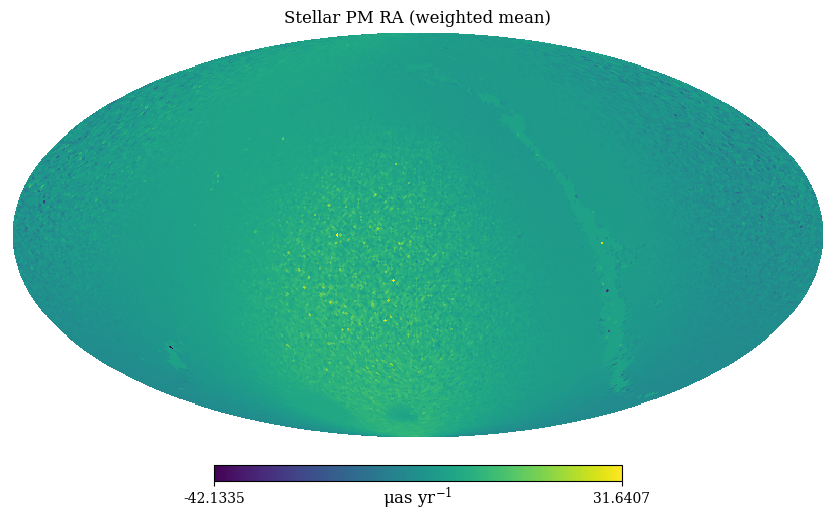

In [37]:
hp.mollview(star_pmra_wm, title='Stellar PM RA (weighted mean)', unit=r'$\mu$as yr$^{-1}$')

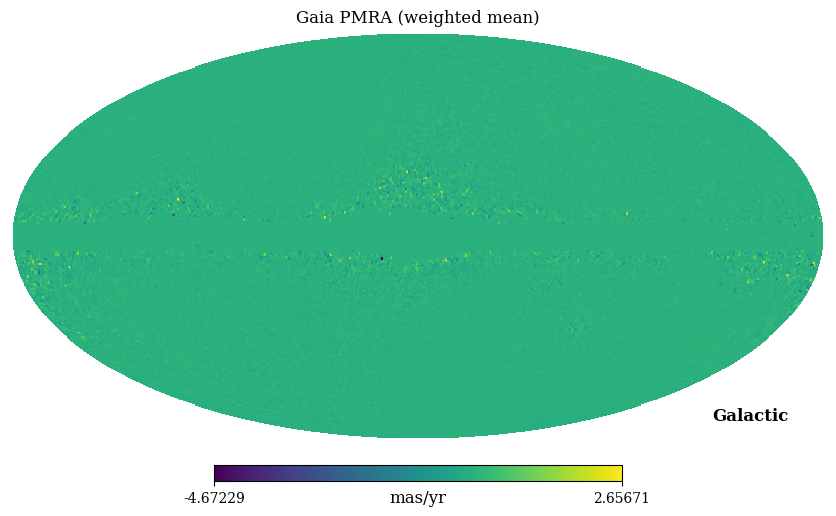

In [38]:
hp.mollview(gaia_pmra_wm, title='Gaia PMRA (weighted mean)', coord = ['C', 'G'], unit='mas/yr')
plt.show()

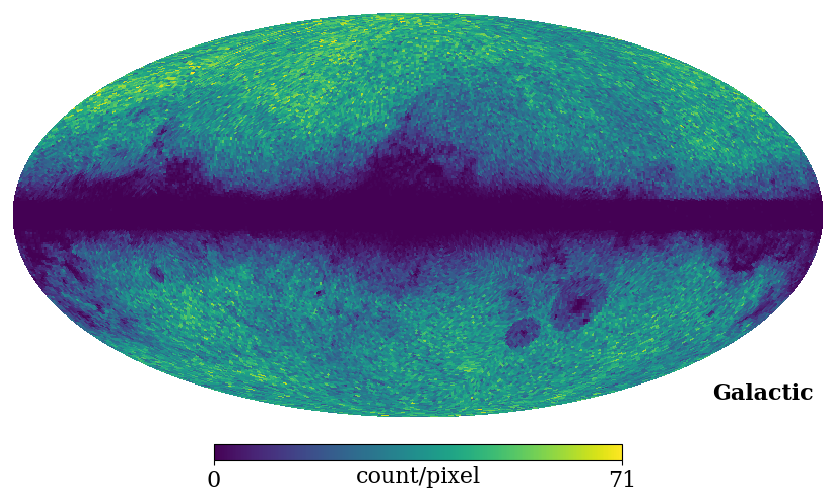

<Figure size 640x480 with 0 Axes>

In [39]:
hp.mollview(n_per_pixel, coord = ['C', 'G'], unit='count/pixel',
                        title='',
            fontsize={'xlabel': 16, 'ylabel': 16, 'title': 16, 'cbar_label': 16}
            )

# Increase colorbar tick and unit-label sizes
fig = plt.gcf()
if len(fig.axes) > 1:
    cbar_ax = fig.axes[-1]
    cbar_ax.tick_params(axis='both', labelsize=16)
    cbar_ax.xaxis.label.set_size(16)
    cbar_ax.yaxis.label.set_size(16)

    # Re-set tick and label fonts explicitly
    for label in cbar_ax.get_xticklabels() + cbar_ax.get_yticklabels():
        label.set_fontfamily('serif')
        label.set_fontsize(16)
plt.show()
plt.savefig(r'output/n_per_pixel_gaia.pdf')



### Scanning / m10 map (Quaia scanning strategy)

(49152,)


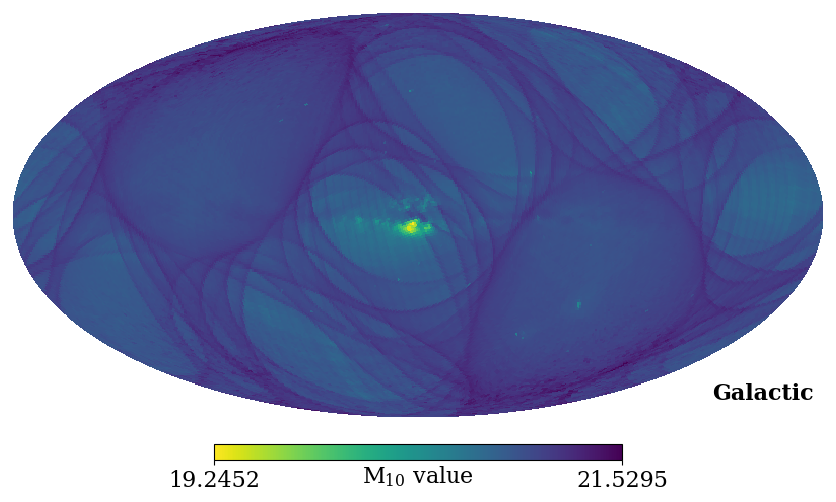

In [40]:
from gaiaunlimited.selectionfunctions import DR3SelectionFunctionTCG
from gaiaunlimited.utils import get_healpix_centers


# Load the default all-sky M10 map (stored at HEALPix order 7)
sf = DR3SelectionFunctionTCG()

# Get the centers of all HEALPix pixels at order 6 (NSIDE=64, 49152 pixels)
coords_order6 = get_healpix_centers(6)

# Query the M10 value at each pixel center
# Use a reference magnitude (e.g. G=21) — the map returns completeness,
# but we want M10 directly from the internal map
m10_col  = sf.m10map[:, 2]          # M10 values, one per order-7 pixel
# m10map rows are already sorted by nested pixel index at order 7
# Build a proper NSIDE=128 healpy array (NESTED)
nside_in = 128
npix_in  = hp.nside2npix(nside_in)   # 196608

m10_fullmap = np.full(npix_in, hp.UNSEEN)
pix_indices = sf.m10map[:, 1].astype(int)   # pixel numbers at order 7
m10_fullmap[pix_indices] = m10_col
nside_out = 64

# Now ud_grade works — degrade from NSIDE=128 to NSIDE=64
m10_map = hp.ud_grade(m10_fullmap, nside_out=nside,
                          order_in='NESTED', order_out='NESTED')
m10_map = hp.reorder(m10_map, n2r=True)  # convert from NESTED to RING ordering

print(m10_map.shape)   # (49152,)

# Visualize
hp.mollview(m10_map,
            coord=['C', 'G'],
            cmap='viridis_r',
            unit=r'$M_{10}$ value',
            title='',
            fontsize={'xlabel': 16, 'ylabel': 16, 'title': 16, 'cbar_label': 16}
            )

# Increase colorbar tick and unit-label sizes
fig = plt.gcf()
if len(fig.axes) > 1:
    cbar_ax = fig.axes[-1]
    cbar_ax.tick_params(axis='both', labelsize=16)
    cbar_ax.xaxis.label.set_size(16)
    cbar_ax.yaxis.label.set_size(16)

    # Re-set tick and label fonts explicitly
    for label in cbar_ax.get_xticklabels() + cbar_ax.get_yticklabels():
        label.set_fontfamily('serif')
        label.set_fontsize(16)
plt.savefig(r'output/scanning.pdf')

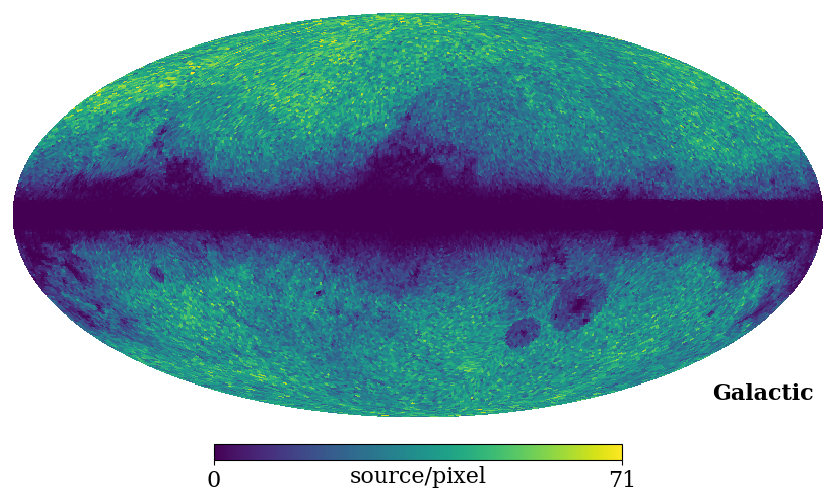

In [41]:
hp.mollview(n_per_pixel,
            coord=['C', 'G'],
            cmap='viridis',
            unit='source/pixel',
            title='',
            fontsize={'xlabel': 16, 'ylabel': 16, 'title': 16, 'cbar_label': 16}
            )

fig = plt.gcf()
if len(fig.axes) > 1:
    cbar_ax = fig.axes[-1]
    cbar_ax.tick_params(axis='both', labelsize=16)
    cbar_ax.xaxis.label.set_size(16)
    cbar_ax.yaxis.label.set_size(16)

    # Re-set tick and label fonts explicitly
    for label in cbar_ax.get_xticklabels() + cbar_ax.get_yticklabels():
        label.set_fontfamily('serif')
        label.set_fontsize(16)
plt.show()


#plt.savefig(r'output/n_per_pixel_test.pdf')

## Build masks

In [42]:
theta = np.radians(90 - gaia_dec)  
phi = np.radians(gaia_ra)  

npix = hp.nside2npix(nside)

 # Get the pixel indices
pix_indices = np.arange(npix)

theta_grid, phi_grid = hp.pix2ang( nside, pix_indices, lonlat = False ) 
ra_grid = phi_grid*180./np.pi
dec_grid = 90 -(theta_grid*180./np.pi)  

icrs_coords = SkyCoord(ra_grid * u.deg, dec_grid * u.deg, frame='icrs')
galactic_coords = icrs_coords.galactic
mask_galactic = np.abs(galactic_coords.b.deg) > 0

In [43]:


# Gaia proper motion: pixel must have valid (non-zero) weighted mean
mask_gaia = (
    (gaia_pmra_full  != 0) & (gaia_pmdec_full  != 0)  &
    mask_galactic
)
# m10: pixel must have a valid (non-UNSEEN) value
mask_m10 = (m10_map > hp.UNSEEN + 1) & mask_galactic

# Stellar density: pixel must contain at least one star
mask_sdens = (nstar_per_pixel > 0) & mask_galactic

# Combined mask for cross-correlations (intersection)
mask_cross = mask_gaia & mask_sdens & mask_m10

mean_sdens = np.sum(nstar_per_pixel * mask_cross) / np.sum(mask_cross)
mean_m10   = np.sum(m10_map * mask_cross)            / np.sum(mask_cross)

nstar_delta = np.where(mask_cross, (nstar_per_pixel - mean_sdens) / mean_sdens, 0.0)
nstar_ms    = np.where(mask_cross,   nstar_per_pixel - mean_sdens, 0.0)

m10_ms    = np.where(mask_cross,   m10_map         - mean_m10,   0.0)


# Apodise for NaMaster
apod_gaia   = nmt.mask_apodization(mask_gaia.astype(float),   APOD_SCALE, APOD_TYPE)
apod_m10    = nmt.mask_apodization(mask_m10.astype(float),    APOD_SCALE, APOD_TYPE)
apod_sdens  = nmt.mask_apodization(mask_sdens.astype(float),  APOD_SCALE, APOD_TYPE)
apod_cross  = nmt.mask_apodization(mask_cross.astype(float),  APOD_SCALE, APOD_TYPE)

apod_gaia   = hp.ud_grade(apod_gaia,  nside_out=nside)
apod_m10    = hp.ud_grade(apod_m10,   nside_out=nside)
apod_sdens  = hp.ud_grade(apod_sdens, nside_out=nside)
apod_cross  = hp.ud_grade(apod_cross, nside_out=nside)

# Zero out UNSEEN pixels in the m10 map before passing to NaMaster
m10_map_clean = np.where(mask_m10, m10_map, 0.0)

f_sky_gaia  = np.mean(apod_gaia**2)
f_sky_m10   = np.mean(apod_m10**2)
f_sky_sdens = np.mean(apod_sdens**2)
f_sky_cross = np.mean(apod_cross**2)
print(f'f_sky: gaia={f_sky_gaia:.3f}  m10={f_sky_m10:.3f}  '
      f'sdens={f_sky_sdens:.3f}  cross={f_sky_cross:.3f}')

# pm_corr field: mean-subtract gaia_pm_corr_full within mask_gaia
mean_corr = np.sum(gaia_pm_corr_full * mask_gaia) / max(np.sum(mask_gaia), 1)
corr_ms   = np.where(mask_gaia, gaia_pm_corr_full - mean_corr, 0.0)


f_sky: gaia=0.715  m10=1.000  sdens=0.856  cross=0.715


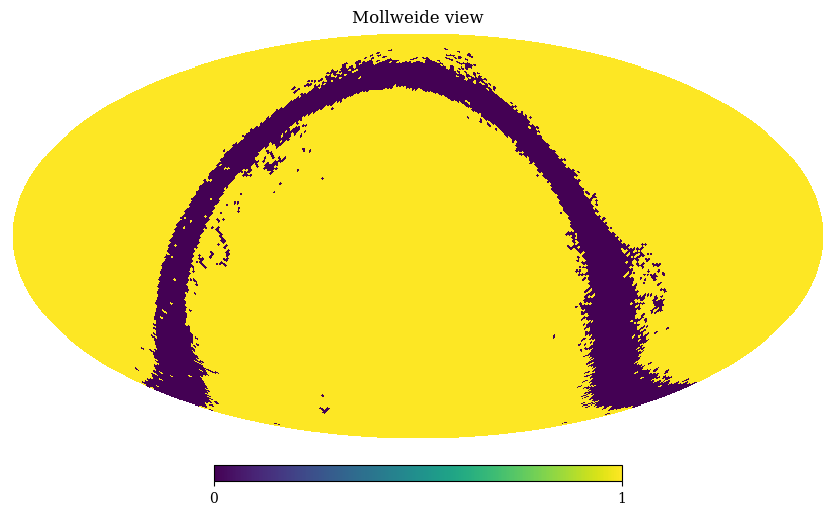

In [44]:
hp.mollview(mask_gaia)


In [45]:
plt.show()

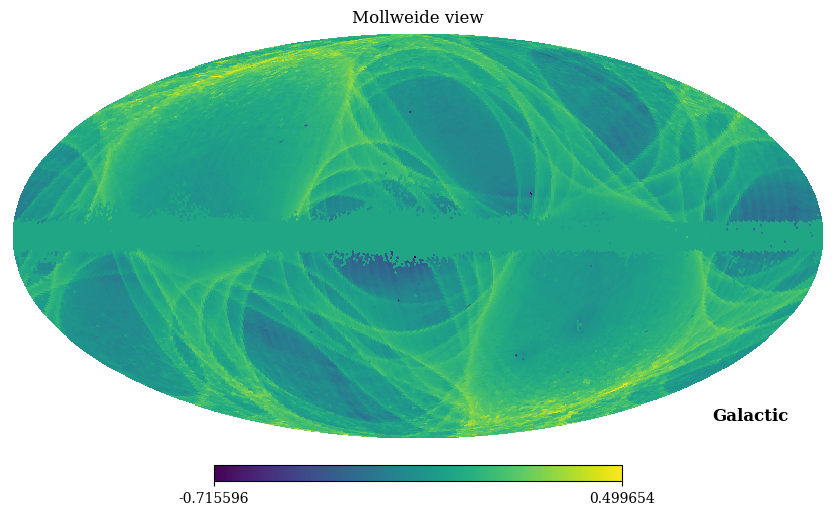

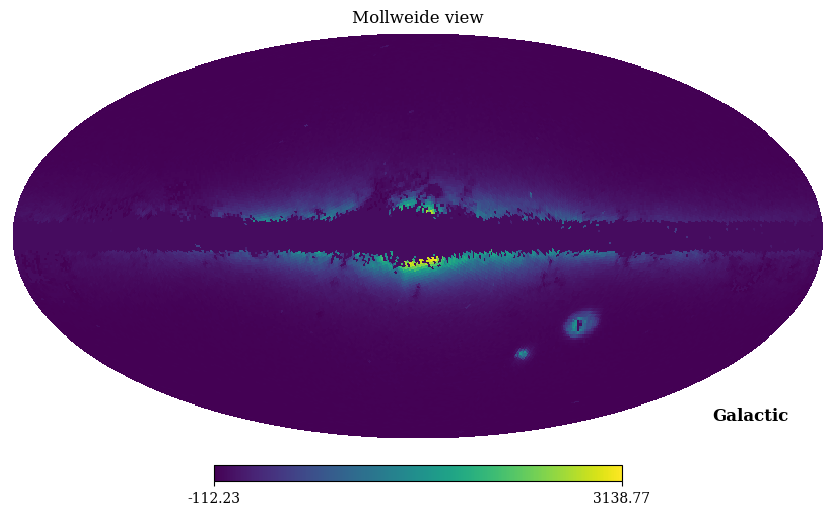

In [46]:
hp.mollview(m10_ms, coord=['C', 'G'])
hp.mollview(nstar_ms, coord=['C', 'G'])
plt.show()

## NaMaster binning and fields

In [47]:
bins = nmt.NmtBin.from_nside_linear(nside, nbin)
ells = bins.get_effective_ells()
print(f'Effective ells (first 10): {ells[:10]}')

# ── Spin-1 : stellar proper motion ──────────────────────────────────────────
# field_pm = nmt.NmtField(mask_gaia, [gaia_pmra_wm, gaia_pmdec_wm], spin=1)
field_pm    = nmt.NmtField(mask_gaia, [-gaia_pmdec_full, gaia_pmra_full], spin=1)


# ── Spin-0 : stellar density ─────────────────────────────────────────────────
field_sdens = nmt.NmtField(apod_sdens, [nstar_ms])

# ── Spin-0 : m10 map ─────────────────────────────────────────────────────────
field_m10 = nmt.NmtField(apod_m10, [m10_ms])

# ── Cross-correlation fields (joint mask) ────────────────────────────────────
# field_pm_x    = nmt.NmtField(mask_gaia, [gaia_pmra_wm, gaia_pmdec_wm], spin=1)
field_pm_x    = nmt.NmtField(mask_gaia, [-gaia_pmdec_full, gaia_pmra_full], spin=1)

field_sdens_x = nmt.NmtField(mask_gaia, [nstar_ms])
field_m10_x   = nmt.NmtField(mask_gaia, [m10_ms])

# ── Spin-0 : pm_corr map ────────────────────────────────────────────────────
# Reuse apod_gaia mask (corr is valid wherever gaia PM is valid)
field_corr   = nmt.NmtField(apod_gaia, [corr_ms])
field_corr_x = nmt.NmtField(mask_gaia, [corr_ms])


Effective ells (first 10): [ 2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]


## Auto power spectra (NaMaster, ell ≥ 2)

In [48]:
# ── 1.  Stellar PM  ×  Stellar PM  (spin-1 auto) ────────────────────────────
ws_pmpm = nmt.NmtWorkspace()
ws_pmpm.compute_coupling_matrix(field_pm, field_pm, bins)

cl_pmpm_coupled   = nmt.compute_coupled_cell(field_pm, field_pm)
cl_pmpm_decoupled = ws_pmpm.decouple_cell(cl_pmpm_coupled)
# Indices: [0]=EE  [1]=EB  [2]=BE  [3]=BB
cl_pm_EE = cl_pmpm_decoupled[0]
cl_pm_BB = cl_pmpm_decoupled[3]

print(f'PM auto EE (first 5): {cl_pm_EE[:5]}')
print(f'PM auto BB (first 5): {cl_pm_BB[:5]}')

PM auto EE (first 5): [3.14333796e-05 1.63997953e-05 8.12304011e-06 1.09279648e-06
 1.07486192e-05]
PM auto BB (first 5): [3.38328603e-06 4.39331376e-05 8.02056182e-06 3.90314953e-05
 1.42642802e-05]


## Cross power spectra (NaMaster, ell ≥ 2)

For spin-1 × spin-0 NaMaster returns 2 components: [0] = E×T, [1] = B×T

In [49]:
# ── 4.  Stellar PM  ×  Stellar density  (spin-1 × spin-0) ──────────────────
ws_pmsd = nmt.NmtWorkspace()
ws_pmsd.compute_coupling_matrix(field_pm_x, field_sdens_x, bins)

cl_pmsd_coupled   = nmt.compute_coupled_cell(field_pm_x, field_sdens_x)
cl_pmsd_decoupled = ws_pmsd.decouple_cell(cl_pmsd_coupled)
cl_pm_x_sdens_E = cl_pmsd_decoupled[0]   # E × density
cl_pm_x_sdens_B = cl_pmsd_decoupled[1]   # B × density

print(f'PM × sdens  E (first 5): {cl_pm_x_sdens_E[:5] *1e3}')
print(f'PM × sdens  B (first 5): {cl_pm_x_sdens_B[:5] * 1e3}')

PM × sdens  E (first 5): [248.57711386  11.84927834  46.01156288   0.65947697 -46.17691605]
PM × sdens  B (first 5): [-135.14948841  304.29018185   41.08593424  -64.54105697   -5.75567026]


In [50]:
# ── 5.  Stellar PM  ×  m10  (spin-1 × spin-0) ──────────────────────────────
ws_pmm10 = nmt.NmtWorkspace()
ws_pmm10.compute_coupling_matrix(field_pm_x, field_m10_x, bins)

cl_pmm10_coupled   = nmt.compute_coupled_cell(field_pm_x, field_m10_x)
cl_pmm10_decoupled = ws_pmm10.decouple_cell(cl_pmm10_coupled)
cl_pm_x_m10_E = cl_pmm10_decoupled[0]    # E × m10
cl_pm_x_m10_B = cl_pmm10_decoupled[1]    # B × m10

print(f'PM × m10   E (first 5): {cl_pm_x_m10_E[:5]}')
print(f'PM × m10   B (first 5): {cl_pm_x_m10_B[:5]}')

PM × m10   E (first 5): [ 4.97874227e-05  8.45883712e-06 -8.42275678e-05  4.23030578e-07
  1.33260626e-04]
PM × m10   B (first 5): [-3.99902577e-05  9.16672596e-05 -5.30328081e-05 -9.90108529e-06
  8.19446698e-06]


In [51]:
# ── 6.  QSO PM  x  Stellar PM  (spin-1 x spin-1) ────────────────────────────
mask_cross_pm = mask_gaia & mask_star_pm
apod_cross_pm = nmt.mask_apodization(mask_cross_pm.astype(float),
                                      APOD_SCALE, APOD_TYPE)
apod_cross_pm = hp.ud_grade(apod_cross_pm, nside_out=nside)

field_qpm_x = nmt.NmtField(apod_cross_pm, [-gaia_pmdec_wm,  gaia_pmra_wm],  spin=1)
field_spm_x = nmt.NmtField(apod_cross_pm, [-star_pmdec_wm,  star_pmra_wm],  spin=1)

# Auto-spectrum of stellar PM (needed for MC fiducial)
ws_spmpm = nmt.NmtWorkspace()
ws_spmpm.compute_coupling_matrix(field_spm_x, field_spm_x, bins)
cl_spmpm_coupled   = nmt.compute_coupled_cell(field_spm_x, field_spm_x)
cl_spmpm_decoupled = ws_spmpm.decouple_cell(cl_spmpm_coupled)
cl_spm_EE = cl_spmpm_decoupled[0]
cl_spm_BB = cl_spmpm_decoupled[3]

# Cross-spectrum
ws_pmxpm = nmt.NmtWorkspace()
ws_pmxpm.compute_coupling_matrix(field_qpm_x, field_spm_x, bins)
cl_pmxpm_coupled   = nmt.compute_coupled_cell(field_qpm_x, field_spm_x)
cl_pmxpm_decoupled = ws_pmxpm.decouple_cell(cl_pmxpm_coupled)

# spin-1 x spin-1 returns [EE, EB, BE, BB]
cl_qpm_x_spm_EE = cl_pmxpm_decoupled[0]
cl_qpm_x_spm_BB = cl_pmxpm_decoupled[3]

print(f'Stellar PM auto  EE (first 5): {cl_spm_EE[:5]}')
print(f'QSO PM x Stellar PM  EE (first 5): {cl_qpm_x_spm_EE[:5]}')
print(f'QSO PM x Stellar PM  BB (first 5): {cl_qpm_x_spm_BB[:5]}')


Stellar PM auto  EE (first 5): [ 1.57151860e+00  2.74387506e+00  1.23892737e-03 -8.94388757e-02
 -2.00748453e-02]
QSO PM x Stellar PM  EE (first 5): [ 3.25252288e-03  1.36923803e-03  3.77223038e-04  1.02121502e-04
 -6.00749861e-05]
QSO PM x Stellar PM  BB (first 5): [-9.91207409e-03 -9.37753878e-04  1.88326548e-03 -8.48009552e-05
  3.44517715e-04]


In [52]:
_ws = nmt.NmtWorkspace()
_ws.compute_coupling_matrix(field_sdens_x, field_sdens_x, bins)
cl_sdens_auto = _ws.decouple_cell(
    nmt.compute_coupled_cell(field_sdens_x, field_sdens_x))[0]

_ws.compute_coupling_matrix(field_m10_x, field_m10_x, bins)
cl_m10_auto = _ws.decouple_cell(
    nmt.compute_coupled_cell(field_m10_x, field_m10_x))[0]

In [53]:
# ── 7.  Gaia PM  ×  pm_corr  (spin-1 × spin-0) ─────────────────────────────
ws_pmcorr = nmt.NmtWorkspace()
ws_pmcorr.compute_coupling_matrix(field_pm_x, field_corr_x, bins)

cl_pmcorr_coupled   = nmt.compute_coupled_cell(field_pm_x, field_corr_x)
cl_pmcorr_decoupled = ws_pmcorr.decouple_cell(cl_pmcorr_coupled)
# spin-1 × spin-0 → [0]=E×T, [1]=B×T
cl_pm_x_corr_E = cl_pmcorr_decoupled[0]
cl_pm_x_corr_B = cl_pmcorr_decoupled[1]

print(f'PM × corr  E (first 5): {cl_pm_x_corr_E[:5]}')
print(f'PM × corr  B (first 5): {cl_pm_x_corr_B[:5]}')


PM × corr  E (first 5): [-1.10173798e-05  8.64695377e-05 -3.23011089e-06 -2.44444935e-05
  7.13791939e-06]
PM × corr  B (first 5): [ 2.60426462e-05  2.08542887e-04  2.76637054e-06  7.26703909e-05
 -2.64407072e-05]


In [54]:
# ── 8.  pm_corr  ×  m10  (spin-0 × spin-0) ─────────────────────────────────
ws_corrm10 = nmt.NmtWorkspace()
ws_corrm10.compute_coupling_matrix(field_corr_x, field_m10_x, bins)

cl_corrm10_coupled   = nmt.compute_coupled_cell(field_corr_x, field_m10_x)
cl_corrm10_decoupled = ws_corrm10.decouple_cell(cl_corrm10_coupled)
cl_corr_x_m10 = cl_corrm10_decoupled[0]

# Auto-spectrum of corr (needed as MC fiducial)
_ws_corr = nmt.NmtWorkspace()
_ws_corr.compute_coupling_matrix(field_corr_x, field_corr_x, bins)
cl_corr_auto = _ws_corr.decouple_cell(
    nmt.compute_coupled_cell(field_corr_x, field_corr_x))[0]

print(f'corr × m10  (first 5): {cl_corr_x_m10[:5]}')
print(f'corr auto   (first 5): {cl_corr_auto[:5]}')


corr × m10  (first 5): [-1.01751356e-03  1.06942476e-04 -3.29853039e-05 -1.15402107e-04
 -9.82400509e-05]
corr auto   (first 5): [2.87663730e-04 3.08921814e-02 3.11832153e-05 3.03946459e-03
 7.44781907e-05]


## ell = 1 via healpy

NaMaster's workspace starts at ell = 2 for spin-1 fields.  
We compute the ell = 1 pseudo-Cl directly from the masked maps using healpy,  
with a simple f_sky correction.

In [55]:
# Use the boolean mask (not apodised) for the healpy ell=1 estimate
mask_hp = mask_cross.astype(float)

# Auto: PM × PM
cl1_pm_EE, cl1_pm_BB = cl_at_ell1_spin1_auto(gaia_pmra_wm, gaia_pmdec_wm, mask_hp, lmax_hp)

# Auto: stellar density
# cl1_sdens = cl_at_ell1_spin0(nstar_ms, nstar_ms, mask_hp)

# Auto: m10
# cl1_m10 = cl_at_ell1_spin0(m10_ms, m10_ms, mask_hp)

# Cross: PM × stellar density
cl1_pm_x_sdens_E, cl1_pm_x_sdens_B = cl_at_ell1_spin1_x_spin0(
    gaia_pmra_wm, gaia_pmdec_wm, nstar_ms, mask_hp, lmax_hp)
# Cross: PM × m10
cl1_pm_x_m10_E, cl1_pm_x_m10_B = cl_at_ell1_spin1_x_spin0(
    gaia_pmra_wm, gaia_pmdec_wm, m10_ms, mask_hp, lmax_hp)

print(f'ell=1  PM EE  : {cl1_pm_EE:.4e}    BB : {cl1_pm_BB:.4e}')
# print(f'ell=1  sdens  : {cl1_sdens:.4e}')
# print(f'ell=1  m10    : {cl1_m10:.4e}')
print(f'ell=1  PM×sdens  E : {cl1_pm_x_sdens_E:.4e}   B : {cl1_pm_x_sdens_B:.4e}')
print(f'ell=1  PM×m10    E : {cl1_pm_x_m10_E:.4e}   B : {cl1_pm_x_m10_B:.4e}')


ell=1  PM EE  : 7.5875e-05    BB : 2.8045e-05
ell=1  PM×sdens  E : 1.3532e+00   B : -2.3492e-02
ell=1  PM×m10    E : -1.5554e-04   B : -4.1212e-07
ell=1  PM×corr   E : 5.8585e-04   B : -7.1620e-04
ell=1  corr×m10    : -1.0099e-03


In [56]:
# ell = 1  QSO PM x Stellar PM  (spin-1 x spin-1)
def cl_at_ell1_spin1_x_spin1(pm_ra_1, pm_dec_1, pm_ra_2, pm_dec_2, mask, lmax):
    """
    Estimate ell=1 pseudo-Cl cross-spectrum between two spin-1 fields.
    Returns (C_ell1_EE, C_ell1_BB).
    """
    alm_E1, alm_B1 = hp.map2alm_spin([-pm_dec_1 * mask,  pm_ra_1 * mask], spin=1, lmax=lmax)
    alm_E2, alm_B2 = hp.map2alm_spin([-pm_dec_2 * mask,  pm_ra_2 * mask], spin=1, lmax=lmax)
    f_sky = np.mean(mask**2)

    alm_E1_l1 = _extract_ell1_alm(alm_E1, lmax)
    alm_B1_l1 = _extract_ell1_alm(alm_B1, lmax)
    alm_E2_l1 = _extract_ell1_alm(alm_E2, lmax)
    alm_B2_l1 = _extract_ell1_alm(alm_B2, lmax)

    cl_EE = hp.alm2cl(alm_E1_l1, alm_E2_l1, lmax=lmax)
    cl_BB = hp.alm2cl(alm_B1_l1, alm_B2_l1, lmax=lmax)
    return cl_EE[1] / f_sky, cl_BB[1] / f_sky

mask_hp_pm = mask_cross_pm.astype(float)
cl1_qpm_x_spm_EE, cl1_qpm_x_spm_BB = cl_at_ell1_spin1_x_spin1(
    gaia_pmra_wm, gaia_pmdec_wm,
    star_pmra_wm, star_pmdec_wm,
    mask_hp_pm, lmax_hp)

print(f'ell=1  QSO PM x Stellar PM  EE : {cl1_qpm_x_spm_EE:.4e}   BB : {cl1_qpm_x_spm_BB:.4e}')


ell=1  QSO PM x Stellar PM  EE : -9.7398e-03   BB : 1.9139e-02


## Variance via Monte Carlo simulation

Strategy:
1. Use the measured power spectra as fiducial inputs.
2. Generate `N_SIMS` Gaussian random field realisations per map.
3. Compute NaMaster power spectra for each realisation.
4. The variance across realisations gives the 1-sigma error bars.

> For cross-spectra the two maps are simulated with their auto-spectra only
> (zero cross-correlation assumed as a null test).  Replace the fiducial
> cross-Cl below if a non-zero signal is expected.

In [57]:
n_ells = len(ells)

def bandpower_to_full_cl(ell_b, cl_b, lmax):
    """Approximate full-ell Cl by constant interpolation of band-powers."""
    cl_full = np.zeros(lmax + 1)
    ell_b   = np.round(ell_b).astype(int)
    for i, ell in enumerate(ell_b):
        if ell <= lmax:
            cl_full[ell] = max(cl_b[i], 0)
    last = 0.0
    for ell in range(lmax + 1):
        if cl_full[ell] > 0:
            last = cl_full[ell]
        elif last > 0:
            cl_full[ell] = last
            
    first = 0.0
    for ell in range(lmax + 1):
        if cl_full[ell] > 0:
            first = cl_full[ell]
            break
    for ell in range(lmax + 1):
        if cl_full[ell] == 0:
            cl_full[ell] = first
        else:
            break

    return cl_full

lmax_sim = 3 * nside - 1

fid_pm_EE = bandpower_to_full_cl(ells, cl_pm_EE,    lmax_sim)
fid_pm_BB = bandpower_to_full_cl(ells, cl_pm_BB,    lmax_sim)
fid_sdens = bandpower_to_full_cl(ells, cl_sdens_auto, lmax_sim)
fid_m10   = bandpower_to_full_cl(ells, cl_m10_auto,   lmax_sim)

# synfast with 4 Cls (TT, EE, BB, TE) generates [T, Q, U]; use Q,U as pmra,pmdec
fid_pm_spin1 = np.array([np.zeros(lmax_sim + 1),
                          fid_pm_EE,
                          fid_pm_BB,
                          np.zeros(lmax_sim + 1)])


fid_spm_EE = bandpower_to_full_cl(ells, cl_spm_EE, lmax_sim)
fid_spm_BB = bandpower_to_full_cl(ells, cl_spm_BB, lmax_sim)

print('Fiducial spectra built.')

Fiducial spectra built.


In [ ]:
rng = np.random.default_rng(42)

sims_pm_EE        = np.zeros((N_SIMS, n_ells))
sims_pm_BB        = np.zeros((N_SIMS, n_ells))
sims_sdens        = np.zeros((N_SIMS, n_ells))
sims_m10          = np.zeros((N_SIMS, n_ells))
sims_pm_x_sdens_E = np.zeros((N_SIMS, n_ells))
sims_pm_x_sdens_B = np.zeros((N_SIMS, n_ells))
sims_pm_x_m10_E   = np.zeros((N_SIMS, n_ells))
sims_pm_x_m10_B   = np.zeros((N_SIMS, n_ells))

sims_l1_pm_EE   = np.zeros(N_SIMS)
sims_l1_pm_BB   = np.zeros(N_SIMS)
sims_l1_sdens   = np.zeros(N_SIMS)
sims_l1_m10     = np.zeros(N_SIMS)
sims_l1_pmxsd_E = np.zeros(N_SIMS)
sims_l1_pmxsd_B = np.zeros(N_SIMS)
sims_l1_pmxm10_E = np.zeros(N_SIMS)
sims_l1_pmxm10_B = np.zeros(N_SIMS)

# Fiducial for corr field (use measured auto-spectrum)

print(f'Running {N_SIMS} simulations...')

for i in range(N_SIMS):
    # ── Gaussian random maps ────────────────────────────────────────────────
    alm_E_pm = hp.synalm(fid_pm_EE, lmax=lmax_sim)
    alm_B_pm = hp.synalm(fid_pm_BB, lmax=lmax_sim)
    m_theta, m_phi = hp.alm2map_spin([alm_E_pm, alm_B_pm], nside, spin=1, lmax=lmax_sim)
    sim_pmra = m_phi
    sim_pmdec = -m_theta



    sim_sdens = hp.synfast(fid_sdens, nside, lmax=lmax_sim, verbose=False)
    sim_m10   = hp.synfast(fid_m10,   nside, lmax=lmax_sim, verbose=False)

    sim_sdens_raw = hp.synfast(fid_sdens, nside, lmax=lmax_sim)
    sim_m10_raw   = hp.synfast(fid_m10,   nside, lmax=lmax_sim)
    sim_sdens_ms  = sim_sdens_raw - np.sum(sim_sdens_raw * mask_gaia) / np.sum(mask_gaia)
    sim_m10_ms    = sim_m10_raw   - np.sum(sim_m10_raw   * mask_gaia) / np.sum(mask_gaia)


    # ── NaMaster fields ─────────────────────────────────────────────────────
    f_pm_i   = nmt.NmtField(mask_gaia,  [-sim_pmdec, sim_pmra], spin=1)
    f_pmx_i  = nmt.NmtField(mask_gaia, [-sim_pmdec, sim_pmra], spin=1)
    f_sdx_i  = nmt.NmtField(mask_gaia, [sim_sdens])
    f_m10x_i  = nmt.NmtField(mask_gaia, [sim_m10])

    # ── Decouple ─────────────────────────────────────────────────────────────
    cl_pm_i    = ws_pmpm.decouple_cell(nmt.compute_coupled_cell(f_pm_i,  f_pm_i))
    cl_pmsd_i  = ws_pmsd.decouple_cell(nmt.compute_coupled_cell(f_pmx_i, f_sdx_i))
    cl_pmm10_i = ws_pmm10.decouple_cell(nmt.compute_coupled_cell(f_pmx_i,  f_m10x_i))

    sims_pm_EE[i]        = cl_pm_i[0]
    sims_pm_BB[i]        = cl_pm_i[3]
    sims_pm_x_sdens_E[i] = cl_pmsd_i[0]
    sims_pm_x_sdens_B[i] = cl_pmsd_i[1]
    sims_pm_x_m10_E[i]   = cl_pmm10_i[0]
    sims_pm_x_m10_B[i]   = cl_pmm10_i[1]

    # ── ell=1 ────────────────────────────────────────────────────────────────
    ee1, bb1 = cl_at_ell1_spin1_auto(sim_pmra, sim_pmdec, mask_gaia, lmax_hp)
    sims_l1_pm_EE[i] = ee1
    sims_l1_pm_BB[i] = bb1

    # Mean-subtract simulated scalar maps within mask_hp to mirror data pipeline
    #sim_sdens_ms = sim_sdens #- np.sum(sim_sdens * mask_hp) / np.sum(mask_hp))/(np.sum(sim_sdens * mask_hp) / np.sum(mask_hp))
    #sim_m10_ms   = sim_m10 #  - np.sum(sim_m10   * mask_hp) / np.sum(mask_hp))/(np.sum(sim_m10   * mask_hp) / np.sum(mask_hp))

    e1, b1 = cl_at_ell1_spin1_x_spin0(sim_pmra, sim_pmdec, sim_sdens_ms, mask_gaia, lmax_hp)
    sims_l1_pmxsd_E[i], sims_l1_pmxsd_B[i] = e1, b1

    e1, b1 = cl_at_ell1_spin1_x_spin0(sim_pmra, sim_pmdec, sim_m10_ms, mask_gaia, lmax_hp)
    sims_l1_pmxm10_E[i], sims_l1_pmxm10_B[i] = e1, b1



    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{N_SIMS}')

print('Done.')

Running 500 simulations...


/tmp/ipykernel_51017/1632065175.py:42: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  sim_sdens = hp.synfast(fid_sdens, nside, lmax=lmax_sim, verbose=False)
/tmp/ipykernel_51017/1632065175.py:43: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  sim_m10   = hp.synfast(fid_m10,   nside, lmax=lmax_sim, verbose=False)


  50/500
  100/500
  150/500
  200/500
  250/500
  300/500
  350/500


In [ ]:
std_pm_EE        = np.std(sims_pm_EE,        axis=0)
std_pm_BB        = np.std(sims_pm_BB,        axis=0)
std_sdens        = np.std(sims_sdens,        axis=0)
std_m10          = np.std(sims_m10,          axis=0)
std_pm_x_sdens_E = np.std(sims_pm_x_sdens_E, axis=0)
std_pm_x_sdens_B = np.std(sims_pm_x_sdens_B, axis=0)
std_pm_x_m10_E   = np.std(sims_pm_x_m10_E,   axis=0)
std_pm_x_m10_B   = np.std(sims_pm_x_m10_B,   axis=0)

std_l1_pm_EE    = np.std(sims_l1_pm_EE)
std_l1_pm_BB    = np.std(sims_l1_pm_BB)
std_l1_sdens    = np.std(sims_l1_sdens)
std_l1_m10      = np.std(sims_l1_m10)
std_l1_pmxsd_E  = np.std(sims_l1_pmxsd_E)
std_l1_pmxsd_B  = np.std(sims_l1_pmxsd_B)
std_l1_pmxm10_E = np.std(sims_l1_pmxm10_E)
std_l1_pmxm10_B = np.std(sims_l1_pmxm10_B)


print('Variance estimated from simulations.')

Variance estimated from simulations.


## Combine ell=1 and ell≥2 results

In [ ]:
ells_full = np.concatenate([[1], ells])

def prepend(val, arr):
    return np.concatenate([[val], arr])

CL_pm_EE        = prepend(cl1_pm_EE,        cl_pm_EE)
CL_pm_BB        = prepend(cl1_pm_BB,        cl_pm_BB)
# CL_sdens        = prepend(cl1_sdens,        cl_sdens_auto)
# CL_m10          = prepend(cl1_m10,          cl_m10_auto)
CL_pm_x_sdens_E = prepend(cl1_pm_x_sdens_E, cl_pm_x_sdens_E)
CL_pm_x_sdens_B = prepend(cl1_pm_x_sdens_B, cl_pm_x_sdens_B)
CL_pm_x_m10_E   = prepend(cl1_pm_x_m10_E,   cl_pm_x_m10_E)
CL_pm_x_m10_B   = prepend(cl1_pm_x_m10_B,   cl_pm_x_m10_B)

ERR_pm_EE        = prepend(std_l1_pm_EE,    std_pm_EE)
ERR_pm_BB        = prepend(std_l1_pm_BB,    std_pm_BB)
ERR_sdens        = prepend(std_l1_sdens,    std_sdens)
ERR_m10          = prepend(std_l1_m10,      std_m10)
ERR_pm_x_sdens_E = prepend(std_l1_pmxsd_E,  std_pm_x_sdens_E)
ERR_pm_x_sdens_B = prepend(std_l1_pmxsd_B,  std_pm_x_sdens_B)
ERR_pm_x_m10_E   = prepend(std_l1_pmxm10_E, std_pm_x_m10_E)
ERR_pm_x_m10_B   = prepend(std_l1_pmxm10_B, std_pm_x_m10_B)

CL_pm_x_corr_E  = prepend(cl1_pm_x_corr_E,  cl_pm_x_corr_E)
CL_pm_x_corr_B  = prepend(cl1_pm_x_corr_B,  cl_pm_x_corr_B)
CL_corr_x_m10   = prepend(cl1_corr_x_m10,   cl_corr_x_m10)


print('Combined ell=1 + ell≥2 arrays ready.')
print(f'ell array: {ells_full[:5]} ... {ells_full[-5:]}')

Combined ell=1 + ell≥2 arrays ready.
ell array: [1. 2. 3. 4. 5.] ... [187. 188. 189. 190. 191.]


In [ ]:
# ── Monte Carlo variance for QSO PM x Stellar PM ────────────────────────────
sims_qpm_x_spm_EE = np.zeros((N_SIMS, n_ells))
sims_qpm_x_spm_BB = np.zeros((N_SIMS, n_ells))
sims_l1_pmxspm_EE = np.zeros(N_SIMS)
sims_l1_pmxspm_BB = np.zeros(N_SIMS)

print(f'Running {N_SIMS} simulations for QSO PM x Stellar PM ...')
for i in range(N_SIMS):
    # Independent Gaussian realisations: QSO PM from fid_pm, stellar PM from fid_spm
    alm_E_q = hp.synalm(fid_pm_EE,  lmax=lmax_sim)
    alm_B_q = hp.synalm(fid_pm_BB,  lmax=lmax_sim)
    alm_E_s = hp.synalm(fid_spm_EE, lmax=lmax_sim)
    alm_B_s = hp.synalm(fid_spm_BB, lmax=lmax_sim)

    mth_q, mph_q = hp.alm2map_spin([alm_E_q, alm_B_q], nside, spin=1, lmax=lmax_sim)
    mth_s, mph_s = hp.alm2map_spin([alm_E_s, alm_B_s], nside, spin=1, lmax=lmax_sim)
    sim_pmra_q =  mph_q;  sim_pmdec_q = -mth_q
    sim_pmra_s =  mph_s;  sim_pmdec_s = -mth_s

    f_q = nmt.NmtField(apod_cross_pm, [-sim_pmdec_q, sim_pmra_q], spin=1)
    f_s = nmt.NmtField(apod_cross_pm, [-sim_pmdec_s, sim_pmra_s], spin=1)

    cl_i = ws_pmxpm.decouple_cell(nmt.compute_coupled_cell(f_q, f_s))
    sims_qpm_x_spm_EE[i] = cl_i[0]
    sims_qpm_x_spm_BB[i] = cl_i[3]

    ee1, bb1 = cl_at_ell1_spin1_x_spin1(
        sim_pmra_q, sim_pmdec_q, sim_pmra_s, sim_pmdec_s, mask_hp_pm, lmax_hp)
    sims_l1_pmxspm_EE[i] = ee1
    sims_l1_pmxspm_BB[i] = bb1

    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{N_SIMS}')

std_qpm_x_spm_EE   = np.std(sims_qpm_x_spm_EE, axis=0)
std_qpm_x_spm_BB   = np.std(sims_qpm_x_spm_BB, axis=0)
std_l1_pmxspm_EE   = np.std(sims_l1_pmxspm_EE)
std_l1_pmxspm_BB   = np.std(sims_l1_pmxspm_BB)

CL_qpm_x_spm_EE  = prepend(cl1_qpm_x_spm_EE,  cl_qpm_x_spm_EE)
CL_qpm_x_spm_BB  = prepend(cl1_qpm_x_spm_BB,  cl_qpm_x_spm_BB)
ERR_qpm_x_spm_EE = prepend(std_l1_pmxspm_EE,   std_qpm_x_spm_EE)
ERR_qpm_x_spm_BB = prepend(std_l1_pmxspm_BB,   std_qpm_x_spm_BB)

print('Done.')


Running 500 simulations for QSO PM x Stellar PM ...
  50/500
  100/500
  150/500
  200/500
  250/500
  300/500
  350/500
  400/500
  450/500
  500/500
Done.


## Plots

In [ ]:
dataset = {0: 'gaia', 1: 'gaia_galcut_20', 2: 'gaia_galcut_30_cut', 3: 'quaia'} 
dataset = dataset[1]
dataset


'gaia_galcut_20'

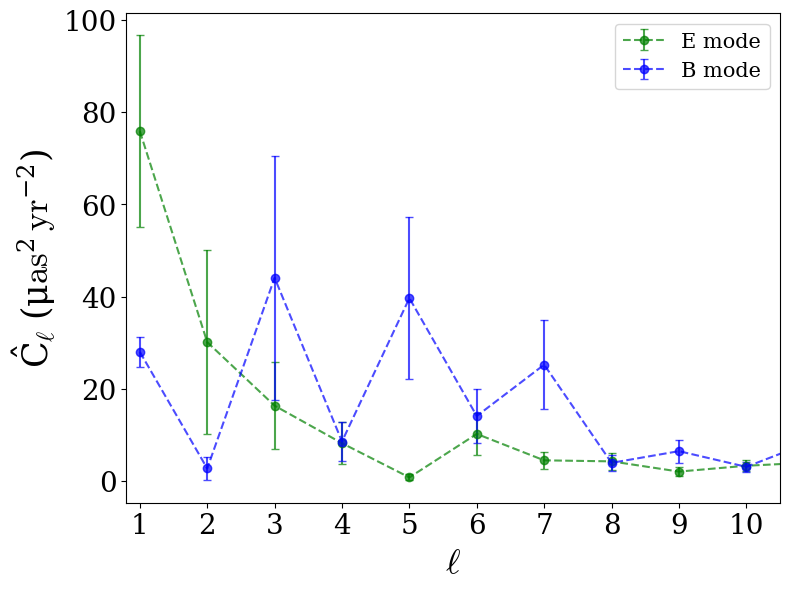

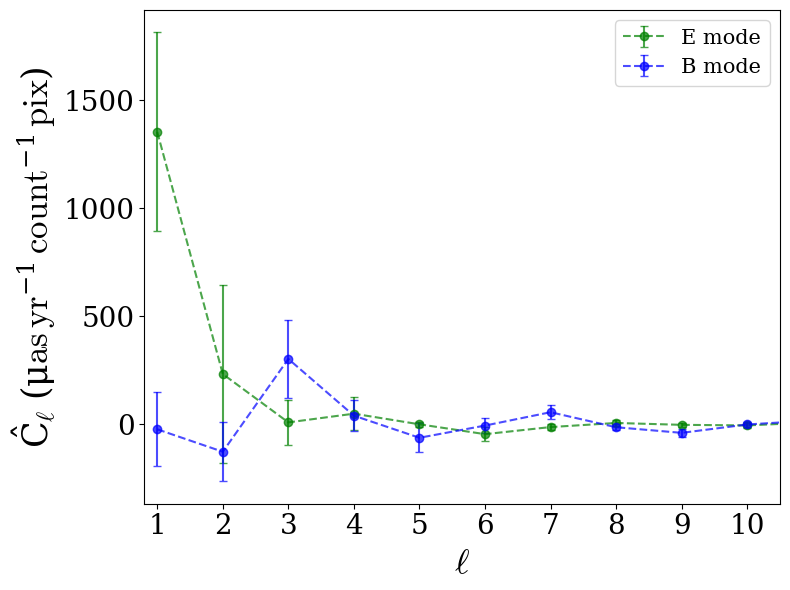

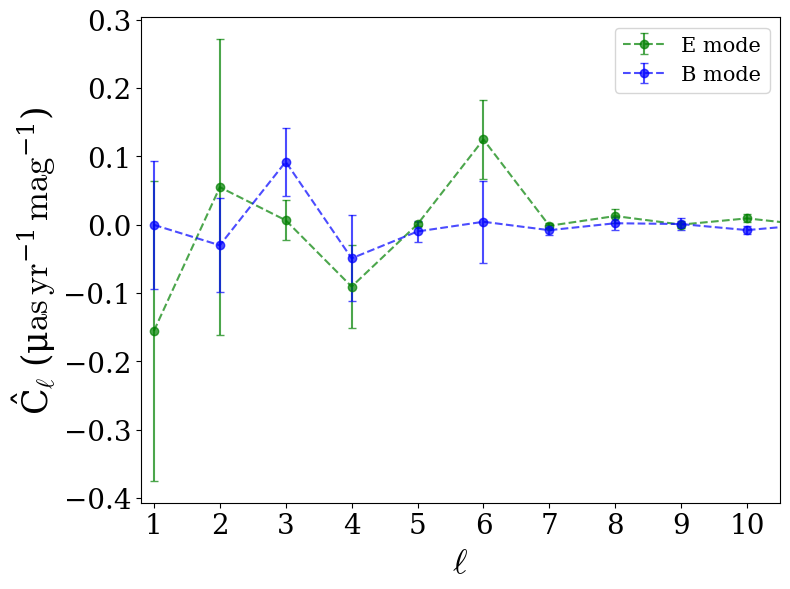

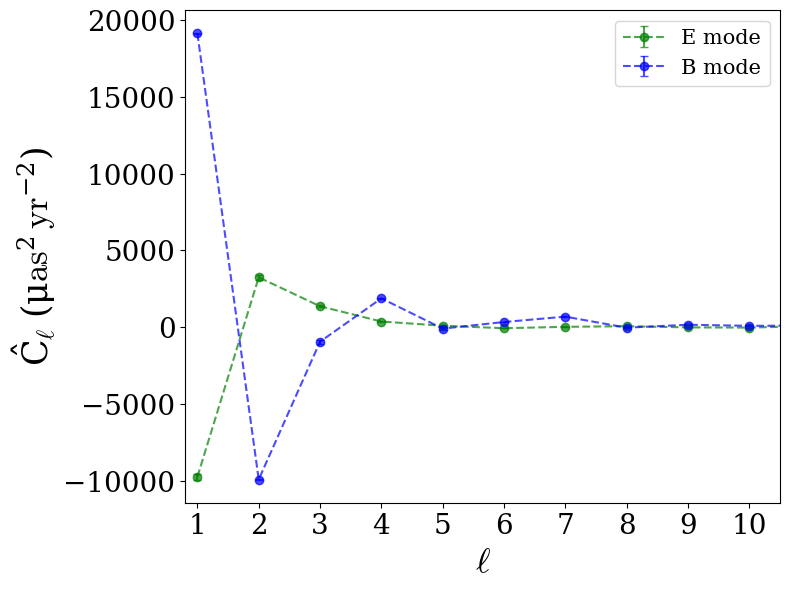

AttributeError: module 'scipy.stats' has no attribute 'erfinv'

In [ ]:
# ── Plot 1: Auto QSO PM × QSO PM ─────────────────────────────────────────────
           

plt.figure(figsize=(8, 6))
plt.errorbar(ells_full, CL_pm_EE * 1e6, yerr=ERR_pm_EE * 1e6,
             fmt='go--', capsize=3, label='E mode', alpha=0.7)
plt.errorbar(ells_full, CL_pm_BB * 1e6, yerr=ERR_pm_BB * 1e6,
             fmt='bo--', capsize=3, label='B mode', alpha=0.7)
plt.xlabel(r'$ \rm  \ell$', fontsize=25)
plt.ylabel(r'$\hat{C}_{\rm  \ell} \, \, (\mu\mathrm{as}^2\,\mathrm{yr}^{-2})$', fontsize=25)
plt.legend(fontsize=15)
plt.xlim(0.8, 10.5)
plt.xticks(np.arange(1, 11, 1), fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(f'output/cl_qpm_auto_{dataset}.pdf')
plt.show()

# ── Plot 2: Cross QSO PM × Stellar density ───────────────────────────────────
plt.figure(figsize=(8, 6))
plt.errorbar(ells_full, CL_pm_x_sdens_E * 1e3, yerr=ERR_pm_x_sdens_E * 1e3,
             fmt='go--', capsize=3, label='E mode', alpha=0.7)
plt.errorbar(ells_full, CL_pm_x_sdens_B * 1e3, yerr=ERR_pm_x_sdens_B * 1e3,
             fmt='bo--', capsize=3, label='B mode', alpha=0.7)
plt.xlabel(r'$ \rm  \ell$', fontsize=25)
plt.ylabel(r'$\hat{C}_{\rm  \ell} \, \,(\mu\mathrm{as}\,\mathrm{yr}^{-1} \, \mathrm{count}^{-1} \, \mathrm{pix})$', fontsize=25)
plt.legend(fontsize=15)
plt.xlim(0.8, 10.5)
plt.xticks(np.arange(1, 11, 1), fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(f'output/cl_qpm_x_sdens_{dataset}.pdf')
plt.show()

# ── Plot 3: Cross QSO PM × m10 (scanning strategy) ───────────────────────────
plt.figure(figsize=(8, 6))
plt.errorbar(ells_full, CL_pm_x_m10_E * 1e3, yerr=ERR_pm_x_m10_E * 1e3,
             fmt='go--', capsize=3, label='E mode', alpha=0.7)
plt.errorbar(ells_full, CL_pm_x_m10_B * 1e3, yerr=ERR_pm_x_m10_B * 1e3,
             fmt='bo--', capsize=3, label='B mode', alpha=0.7)
plt.xlabel(r'$ \rm  \ell$', fontsize=25)
plt.ylabel(r'$\hat{C}_{\rm  \ell} \, \, (\mu\mathrm{as}\,\mathrm{yr}^{-1}\,\mathrm{mag}^{-1})$', fontsize=25)
plt.legend(fontsize=15)
plt.xlim(0.8, 10.5)
plt.xticks(np.arange(1, 11, 1), fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(f'output/cl_qpm_x_m10_{dataset}.pdf')
plt.show()

# ── Plot 4: Cross QSO PM x Stellar PM ───────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.errorbar(ells_full, CL_qpm_x_spm_EE * 1e6, yerr=ERR_qpm_x_spm_EE * 1e6,
             fmt='go--', capsize=3, label='E mode', alpha=0.7)
plt.errorbar(ells_full, CL_qpm_x_spm_BB * 1e6, yerr=ERR_qpm_x_spm_BB * 1e6,
             fmt='bo--', capsize=3, label='B mode', alpha=0.7)
plt.xlabel(r'$ \rm  \ell$', fontsize=25)
plt.ylabel(r'$\hat{C}_{\rm  \ell} \, \, (\mu\mathrm{as}^2\,\mathrm{yr}^{-2})$', fontsize=25)
plt.legend(fontsize=15)
plt.xlim(0.8, 10.5)
plt.xticks(np.arange(1, 11, 1), fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(f'output/cl_qpm_x_spm_{dataset}.pdf')
plt.show()

# Significance
from scipy import stats as _stats
for CL, ERR, label in zip(
        [CL_qpm_x_spm_EE,  CL_qpm_x_spm_BB],
        [ERR_qpm_x_spm_EE, ERR_qpm_x_spm_BB],
        ['E mode', 'B mode']):
    mask10 = (ells_full >= 1) & (ells_full <= 10)
    chi2 = np.sum((CL[mask10] / ERR[mask10])**2)
    dof  = mask10.sum()
    p    = _stats.chi2.sf(chi2, dof)
    nsig = np.sqrt(2) * _stats.erfinv(1 - p)
    print(f'QSO PM x Stellar PM  {label}: chi2/dof = {chi2:.2f}/{dof}  '
          f'p = {p:.4f}  ({nsig:.2f} sigma)')


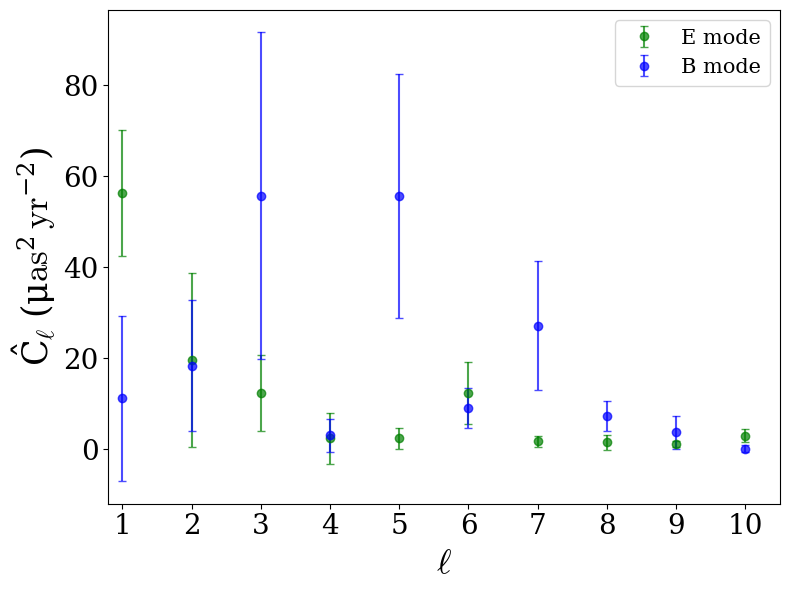

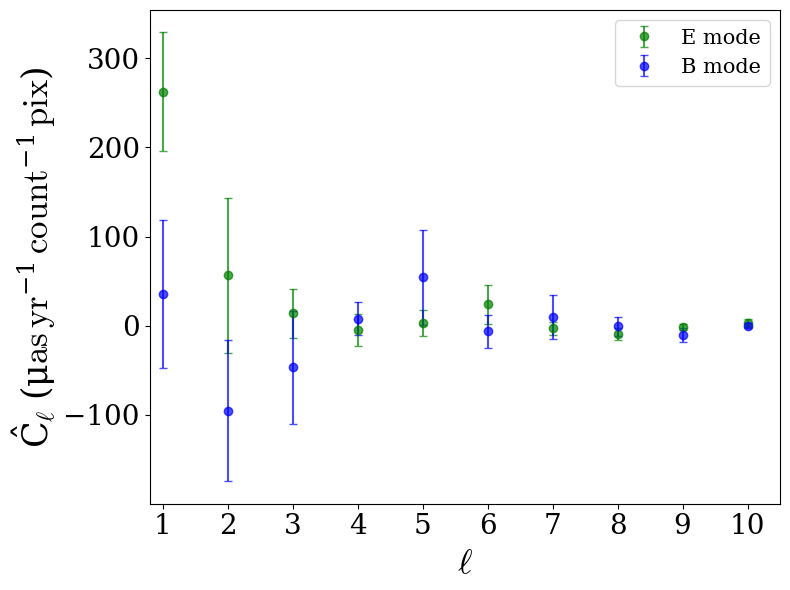

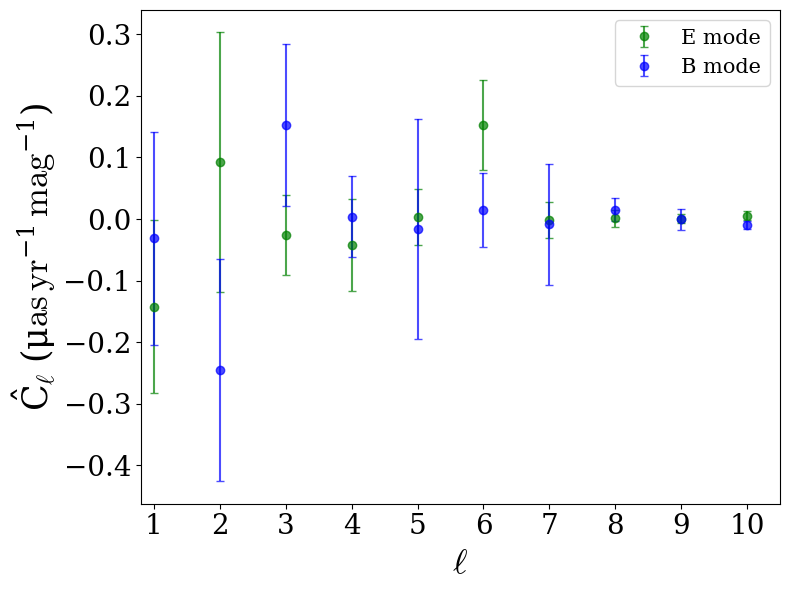

In [ ]:
# ── Plot 1: Auto QSO PM × QSO PM ─────────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.errorbar(ells_full, CL_pm_EE * 1e6, yerr=ERR_pm_EE * 1e6,
             fmt='go', capsize=3, label='E mode', alpha=0.7)
plt.errorbar(ells_full, CL_pm_BB * 1e6, yerr=ERR_pm_BB * 1e6,
             fmt='bo', capsize=3, label='B mode', alpha=0.7)
plt.xlabel(r'$ \rm  \ell$', fontsize=25)
plt.ylabel(r'$\hat{C}_{\rm  \ell} \, \, (\mu\mathrm{as}^2\,\mathrm{yr}^{-2})$', fontsize=25)
plt.legend(fontsize=15)
plt.xlim(0.8, 10.5)
plt.xticks(np.arange(1, 11, 1), fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(f'output/cl_qpm_auto_{dataset}_non_connected.pdf')
plt.show()

# ── Plot 2: Cross QSO PM × Stellar density ───────────────────────────────────
plt.figure(figsize=(8, 6))
plt.errorbar(ells_full, CL_pm_x_sdens_E * 1e3, yerr=ERR_pm_x_sdens_E * 1e3,
             fmt='go', capsize=3, label='E mode', alpha=0.7)
plt.errorbar(ells_full, CL_pm_x_sdens_B * 1e3, yerr=ERR_pm_x_sdens_B * 1e3,
             fmt='bo', capsize=3, label='B mode', alpha=0.7)
plt.xlabel(r'$ \rm  \ell$', fontsize=25)
plt.ylabel(r'$\hat{C}_{\rm  \ell} \, \,(\mu\mathrm{as}\,\mathrm{yr}^{-1} \, \mathrm{count}^{-1} \, \mathrm{pix})$', fontsize=25)
plt.legend(fontsize=15)
plt.xlim(0.8, 10.5)
plt.xticks(np.arange(1, 11, 1), fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(f'output/cl_qpm_x_sdens_{dataset}_non_connected.pdf')
plt.show()

# ── Plot 3: Cross QSO PM × m10 (scanning strategy) ───────────────────────────
plt.figure(figsize=(8, 6))
plt.errorbar(ells_full, CL_pm_x_m10_E * 1e3, yerr=ERR_pm_x_m10_E * 1e3,
             fmt='go', capsize=3, label='E mode', alpha=0.7)
plt.errorbar(ells_full, CL_pm_x_m10_B * 1e3, yerr=ERR_pm_x_m10_B * 1e3,
             fmt='bo', capsize=3, label='B mode', alpha=0.7)
plt.xlabel(r'$ \rm  \ell$', fontsize=25)
plt.ylabel(r'$\hat{C}_{\rm  \ell} \, \, (\mu\mathrm{as}\,\mathrm{yr}^{-1}\,\mathrm{mag}^{-1})$', fontsize=25)
plt.legend(fontsize=15)
plt.xlim(0.8, 10.5)
plt.xticks(np.arange(1, 11, 1), fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(f'output/cl_qpm_x_m10_{dataset}_non_connected.pdf')
plt.show()

## Summary table

In [ ]:
from scipy import stats

def evaluate_cross_spectrum(CL, ERR, label, ell_min=1, ell_max=10):
    """
    Test whether a cross-spectrum is consistent with zero.

    Reports:
      - Per-ell SNR = Cl / sigma_l
      - Chi-squared test (H0: all Cl = 0)
      - Weighted-mean global SNR
      - Bayes factor BF01 (H0: zero signal vs H1: non-zero constant amplitude)
        using a Gaussian reference prior with width = prior_scale
    """
    sel  = (ells_full >= ell_min) & (ells_full <= ell_max)
    cl   = CL[sel]
    err  = ERR[sel]
    ells = ells_full[sel]
    n    = len(cl)

    # ── Per-ell SNR ───────────────────────────────────────────────────────────
    snr_per_ell = cl / err

    # ── Chi-squared test ──────────────────────────────────────────────────────
    chi2_val = np.sum(snr_per_ell**2)
    p_val    = stats.chi2.sf(chi2_val, df=n)
    # convert two-tailed p-value to Gaussian sigma
    sigma_eq = stats.norm.isf(p_val / 2) if p_val > 0 else np.inf

    # ── Weighted mean and global SNR ──────────────────────────────────────────
    w           = 1.0 / err**2
    cl_wm       = np.sum(w * cl) / np.sum(w)          # weighted mean Cl
    err_wm      = 1.0 / np.sqrt(np.sum(w))            # its uncertainty
    global_snr  = cl_wm / err_wm                       # sigma from zero

    # ── Bayes factor BF10 ─────────────────────────────────────────────────────
    # Model H0: Cl_l = 0
    # Model H1: Cl_l = A for all l, A ~ N(0, sigma_prior^2)
    # sigma_prior = std of the Cl values (empirical scale of fluctuations)
    # Analytically: BF10 = sigma_prior/sigma_post * exp(0.5 * mu_post^2 / sigma_post^2)
    # where sigma_post^2 = 1/(sum(w) + 1/sigma_prior^2), mu_post = sigma_post^2 * sum(w*cl)
    sigma_prior = np.std(cl) if np.std(cl) > 0 else err_wm
    sigma_post2 = 1.0 / (np.sum(w) + 1.0 / sigma_prior**2)
    mu_post     = sigma_post2 * np.sum(w * cl)
    log_BF10    = (0.5 * np.log(sigma_post2 / sigma_prior**2)
                   + 0.5 * mu_post**2 / sigma_post2)
    BF10 = np.exp(log_BF10)
    # BF10 > 1 favours H1 (signal); BF10 < 1 favours H0 (zero)
    # Jeffreys scale: BF10 > 3 → moderate evidence, > 10 → strong, > 100 → decisive

    print(f'\n{"─"*60}')
    print(f'  {label}  (ℓ = {ell_min}–{ell_max},  n = {n})')
    print(f'{"─"*60}')
    print(f'  Chi2/dof  = {chi2_val:.2f}/{n}  →  p = {p_val:.4f}  '
          f'({sigma_eq:.2f}σ from zero)')
    print(f'  Global SNR (weighted mean):  {global_snr:.2f}σ  '
          f'(Cl_mean = {cl_wm:.3e} ± {err_wm:.3e})')
    print(f'  Bayes factor BF10 = {BF10:.3f}  '
          f'({"favours SIGNAL" if BF10 > 1 else "favours ZERO"})')
    print(f'  Per-ell SNR:')
    for ell, s in zip(ells, snr_per_ell):
        flag = '  ← {:.1f}σ'.format(abs(s)) if abs(s) > 2 else ''
        print(f'    ℓ = {ell:4.0f}:  {s:+.2f}σ{flag}')

    return dict(chi2=chi2_val, p=p_val, sigma=sigma_eq,
                global_snr=global_snr, BF10=BF10, snr_per_ell=snr_per_ell)

print('='*60)
print('  CONSISTENCY TESTS: cross-spectra vs zero')
print('='*60)

res_sdE  = evaluate_cross_spectrum(CL_pm_x_sdens_E, ERR_pm_x_sdens_E,
                                   'PM × stellar density  (E mode)')
res_sdB  = evaluate_cross_spectrum(CL_pm_x_sdens_B, ERR_pm_x_sdens_B,
                                   'PM × stellar density  (B mode)')
res_m10E = evaluate_cross_spectrum(CL_pm_x_m10_E,   ERR_pm_x_m10_E,
                                   'PM × m10 scanning     (E mode)')
res_m10B = evaluate_cross_spectrum(CL_pm_x_m10_B,   ERR_pm_x_m10_B,
                                   'PM × m10 scanning     (B mode)')

  CONSISTENCY TESTS: cross-spectra vs zero

────────────────────────────────────────────────────────────
  PM × stellar density  (E mode)  (ℓ = 1–10,  n = 10)
────────────────────────────────────────────────────────────
  Chi2/dof  = 20.50/10  →  p = 0.0249  (2.24σ from zero)
  Global SNR (weighted mean):  -0.20σ  (Cl_mean = -4.480e-04 ± 2.279e-03)
  Bayes factor BF10 = 0.030  (favours ZERO)
  Per-ell SNR:
    ℓ =    1:  +3.95σ  ← 4.0σ
    ℓ =    2:  +0.65σ
    ℓ =    3:  +0.50σ
    ℓ =    4:  -0.29σ
    ℓ =    5:  +0.20σ
    ℓ =    6:  +1.08σ
    ℓ =    7:  -0.46σ
    ℓ =    8:  -1.42σ
    ℓ =    9:  -0.39σ
    ℓ =   10:  +0.74σ

────────────────────────────────────────────────────────────
  PM × stellar density  (B mode)  (ℓ = 1–10,  n = 10)
────────────────────────────────────────────────────────────
  Chi2/dof  = 5.51/10  →  p = 0.8549  (0.18σ from zero)
  Global SNR (weighted mean):  -0.41σ  (Cl_mean = -1.105e-03 ± 2.674e-03)
  Bayes factor BF10 = 0.074  (favours ZERO)
  Per-ell S

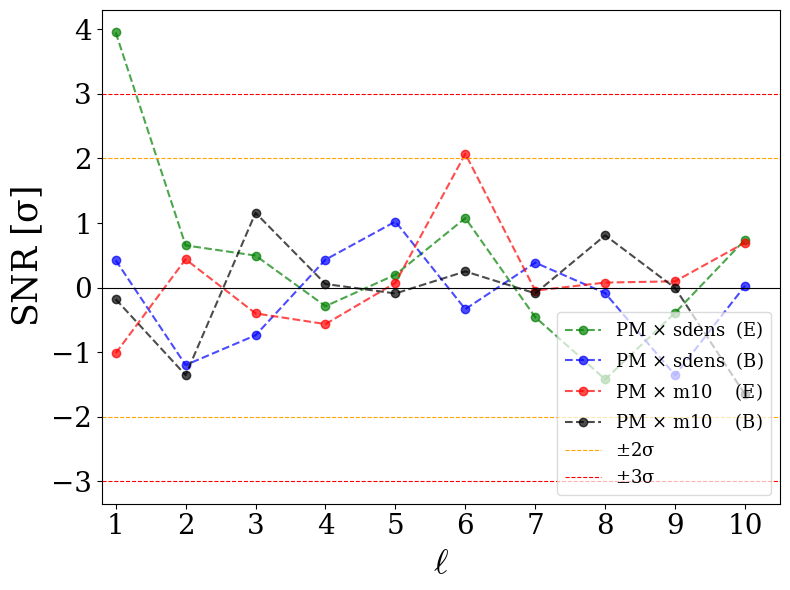

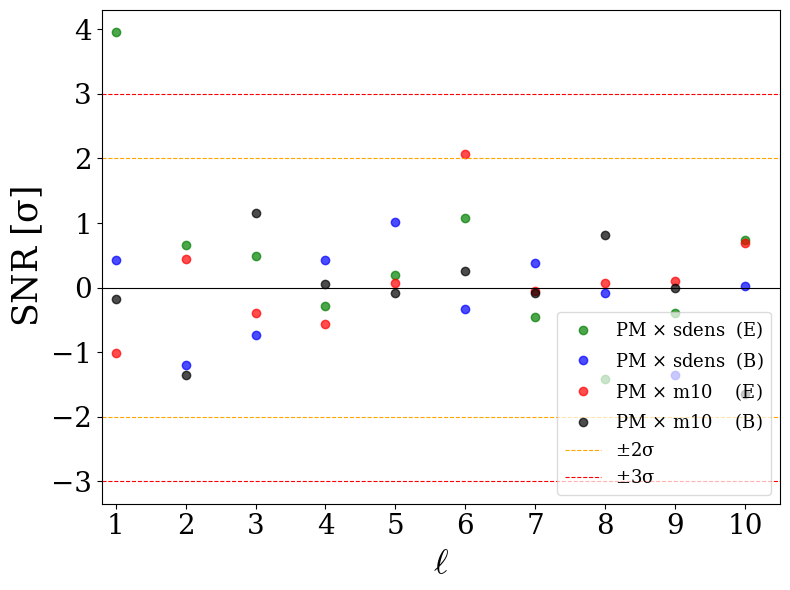

In [ ]:
ell_plot = ells_full[(ells_full >= 1) & (ells_full <= 10)]

plt.figure(figsize=(8, 6))
plt.plot(ell_plot, res_sdE['snr_per_ell'],  'go--', label=r'PM $\times$ sdens  (E)', alpha=0.7)
plt.plot(ell_plot, res_sdB['snr_per_ell'],  'bo--', label=r'PM $\times$ sdens  (B)', alpha=0.7)
plt.plot(ell_plot, res_m10E['snr_per_ell'], 'ro--', label=r'PM $\times$ m10    (E)', alpha=0.7)
plt.plot(ell_plot, res_m10B['snr_per_ell'], 'ko--', label=r'PM $\times$ m10    (B)', alpha=0.7)
plt.axhline(0,  color='k',      lw=0.8)
plt.axhline( 2, color='orange', lw=0.8, ls='--', label=r'$\pm2\sigma$')
plt.axhline(-2, color='orange', lw=0.8, ls='--')
plt.axhline( 3, color='r',      lw=0.8, ls='--',  label=r'$\pm3\sigma$')
plt.axhline(-3, color='r',      lw=0.8, ls='--')
plt.xlabel(r'$ \rm  \ell$', fontsize=25)
plt.ylabel(r'SNR $[\sigma]$', fontsize=25)
plt.xlim(0.8, 10.5)
plt.xticks(np.arange(1, 11), fontsize=20)
plt.yticks(fontsize=20)
plt.legend(loc = 'lower right', fontsize=13, framealpha = 0.7)
plt.tight_layout()
plt.savefig(f'output/snr_per_ell_{dataset}.pdf')
plt.show()



plt.figure(figsize=(8, 6))
plt.plot(ell_plot, res_sdE['snr_per_ell'],  'go', label=r'PM $\times$ sdens  (E)', alpha=0.7)
plt.plot(ell_plot, res_sdB['snr_per_ell'],  'bo', label=r'PM $\times$ sdens  (B)', alpha=0.7)
plt.plot(ell_plot, res_m10E['snr_per_ell'], 'ro', label=r'PM $\times$ m10    (E)', alpha=0.7)
plt.plot(ell_plot, res_m10B['snr_per_ell'], 'ko', label=r'PM $\times$ m10    (B)', alpha=0.7)
plt.axhline(0,  color='k',      lw=0.8)
plt.axhline( 2, color='orange', lw=0.8, ls='--', label=r'$\pm2\sigma$')
plt.axhline(-2, color='orange', lw=0.8, ls='--')
plt.axhline( 3, color='r',      lw=0.8, ls='--',  label=r'$\pm3\sigma$')
plt.axhline(-3, color='r',      lw=0.8, ls='--')
plt.xlabel(r'$ \rm  \ell$', fontsize=25)
plt.ylabel(r'SNR $[\sigma]$', fontsize=25)
plt.xlim(0.8, 10.5)
plt.xticks(np.arange(1, 11), fontsize=20)
plt.legend(loc = 'lower right', fontsize=13, framealpha = 0.7)

plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(f'output/snr_per_ell_{dataset}_non_connected.pdf')
plt.show()

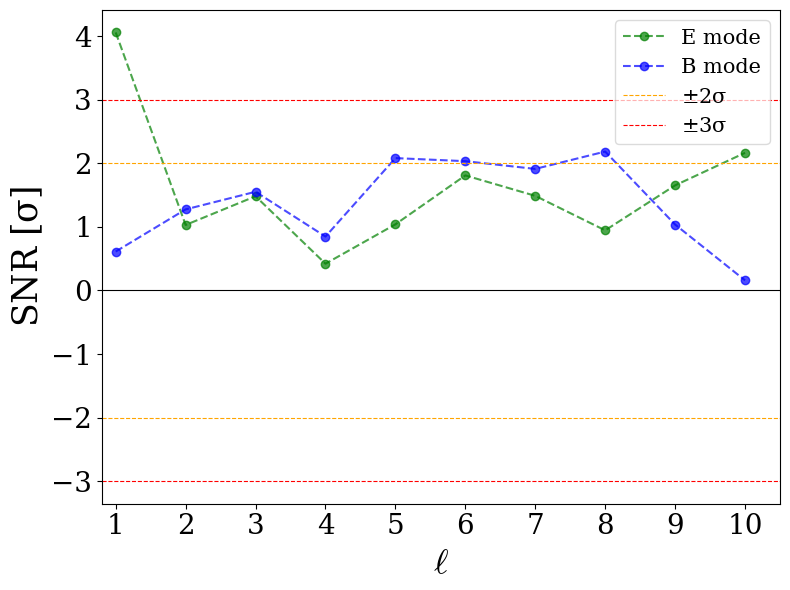

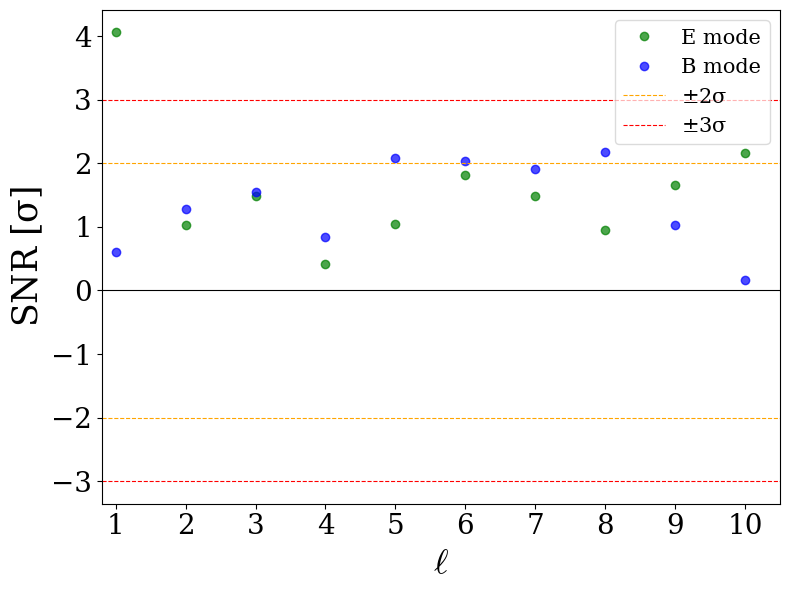

In [ ]:
snr_pm_EE = CL_pm_EE / ERR_pm_EE
snr_pm_BB = CL_pm_BB / ERR_pm_BB

plt.figure(figsize=(8, 6))
plt.plot(ell_plot, snr_pm_EE[ells_full <= 10], 'go--', label='E mode', alpha=0.7)
plt.plot(ell_plot, snr_pm_BB[ells_full <= 10], 'bo--', label='B mode', alpha=0.7)
plt.axhline(0,  color='k',      lw=0.8)
plt.axhline( 2, color='orange', lw=0.8, ls='--', label=r'$\pm2\sigma$')
plt.axhline(-2, color='orange', lw=0.8, ls='--')
plt.axhline( 3, color='r',      lw=0.8, ls='--', label=r'$\pm3\sigma$')
plt.axhline(-3, color='r',      lw=0.8, ls='--')
plt.xlabel(r'$\rm \ell$', fontsize=25)
plt.ylabel(r'SNR $[\sigma]$', fontsize=25)
plt.xlim(0.8, 10.5)
plt.xticks(np.arange(1, 11), fontsize=20)
plt.yticks(fontsize=20)
plt.legend(loc = 'upper right', fontsize=15, framealpha=0.7)
plt.tight_layout()
plt.savefig(f'output/snr_pm_auto_{dataset}.pdf')
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(ell_plot, snr_pm_EE[ells_full <= 10], 'go', label='E mode', alpha=0.7)
plt.plot(ell_plot, snr_pm_BB[ells_full <= 10], 'bo', label='B mode', alpha=0.7)
plt.axhline(0,  color='k',      lw=0.8)
plt.axhline( 2, color='orange', lw=0.8, ls='--', label=r'$\pm2\sigma$')
plt.axhline(-2, color='orange', lw=0.8, ls='--')
plt.axhline( 3, color='r',      lw=0.8, ls='--', label=r'$\pm3\sigma$')
plt.axhline(-3, color='r',      lw=0.8, ls='--')
plt.xlabel(r'$\rm \ell$', fontsize=25)
plt.ylabel(r'SNR $[\sigma]$', fontsize=25)
plt.xlim(0.8, 10.5)
plt.xticks(np.arange(1, 11), fontsize=20)
plt.yticks(fontsize=20)
plt.legend(loc = 'upper right', fontsize=15, framealpha=0.7)
plt.tight_layout()
plt.savefig(f'output/snr_pm_auto_{dataset}_non_connected.pdf')
plt.show()

## Fully NaMaster: dipole + higher multipoles (ell=1 via custom NmtBin)

In [60]:
# ── Custom NmtBin: ell=1 as its own bandpower (index 0), then nbin=1 per ell ─
lmax_nmt = 3 * nside - 1
ells_arr = np.arange(lmax_nmt + 1, dtype=np.int32)
bpws     = np.full(lmax_nmt + 1, -1, dtype=np.int32)
bpws[1]  = 0                    # dipole: bandpower 0
band_idx = 1
for ell in range(2, lmax_nmt + 1):
    bpws[ell] = band_idx
    band_idx += 1
bins_d1 = nmt.NmtBin(ells=ells_arr, bpws=bpws,
                      weights=np.ones(lmax_nmt + 1), lmax=lmax_nmt)
ells_d1 = bins_d1.get_effective_ells()
print(f'bins_d1 first 5 ells: {ells_d1[:5]}')   # should start at 1

# ── Joint boolean mask (no apodization) ──────────────────────────────────────
mask_all = (mask_gaia & mask_star_pm & mask_cross).astype(float)
print(f'f_sky = {mask_all.mean():.3f}')

# ── NaMaster fields (purify_e/b not supported for spin-1) ────────────────────
f_qpm_d1   = nmt.NmtField(mask_all, [-gaia_pmdec_wm, gaia_pmra_wm], spin=1)
f_sdens_d1 = nmt.NmtField(mask_all, [nstar_ms])
f_m10_d1   = nmt.NmtField(mask_all, [m10_ms])
f_spm_d1   = nmt.NmtField(mask_all, [-star_pmdec_wm, star_pmra_wm], spin=1)
f_corr_d1  = nmt.NmtField(mask_all, [corr_ms])

# ── Workspaces ────────────────────────────────────────────────────────────────
print('Computing coupling matrices...')
ws_d1_auto  = nmt.NmtWorkspace()
ws_d1_auto.compute_coupling_matrix(f_qpm_d1, f_qpm_d1,   bins_d1)
ws_d1_sdens = nmt.NmtWorkspace()
ws_d1_sdens.compute_coupling_matrix(f_qpm_d1, f_sdens_d1, bins_d1)
ws_d1_m10   = nmt.NmtWorkspace()
ws_d1_m10.compute_coupling_matrix(f_qpm_d1,   f_m10_d1,   bins_d1)
ws_d1_spm   = nmt.NmtWorkspace()
ws_d1_spm.compute_coupling_matrix(f_qpm_d1,   f_spm_d1,   bins_d1)
ws_d1_pmcorr = nmt.NmtWorkspace()
ws_d1_pmcorr.compute_coupling_matrix(f_qpm_d1, f_corr_d1, bins_d1)
ws_d1_corrm10 = nmt.NmtWorkspace()
ws_d1_corrm10.compute_coupling_matrix(f_corr_d1, f_m10_d1, bins_d1)
ws_d1_corr_auto = nmt.NmtWorkspace()
ws_d1_corr_auto.compute_coupling_matrix(f_corr_d1, f_corr_d1, bins_d1)
print('Done.')


bins_d1 first 5 ells: [1. 2. 3. 4. 5.]
f_sky = 0.879
Computing coupling matrices...
Done.


In [61]:
# ── Data power spectra ────────────────────────────────────────────────────────
def decouple_d1(ws, f1, f2):
    return ws.decouple_cell(nmt.compute_coupled_cell(f1, f2))

# Auto: QSO PM x QSO PM  -> [EE, EB, BE, BB]
cl_d1_auto  = decouple_d1(ws_d1_auto,  f_qpm_d1, f_qpm_d1)
# Cross: QSO PM x stellar density  -> [E, B]
cl_d1_sdens = decouple_d1(ws_d1_sdens, f_qpm_d1, f_sdens_d1)
# Cross: QSO PM x m10  -> [E, B]
cl_d1_m10   = decouple_d1(ws_d1_m10,   f_qpm_d1, f_m10_d1)
# Cross: QSO PM x stellar PM  -> [EE, EB, BE, BB]
cl_d1_spm   = decouple_d1(ws_d1_spm,   f_qpm_d1, f_spm_d1)

# Stellar PM auto-spectrum using mask_all (same mask as MC) -> correct fiducial amplitude
ws_d1_spm_auto = nmt.NmtWorkspace()
ws_d1_spm_auto.compute_coupling_matrix(f_spm_d1, f_spm_d1, bins_d1)
cl_d1_spm_auto = ws_d1_spm_auto.decouple_cell(nmt.compute_coupled_cell(f_spm_d1, f_spm_d1))
cl_d1_spm_auto_EE = cl_d1_spm_auto[0]
cl_d1_spm_auto_BB = cl_d1_spm_auto[3]

# QSO PM auto-spectrum fiducial from this pipeline (mask_all)
cl_d1_auto_EE_fid = cl_d1_auto[0]
cl_d1_auto_BB_fid = cl_d1_auto[3]

CL_d1_auto_EE = cl_d1_auto[0];   CL_d1_auto_BB = cl_d1_auto[3]
CL_d1_sdens_E = cl_d1_sdens[0];  CL_d1_sdens_B = cl_d1_sdens[1]
CL_d1_m10_E   = cl_d1_m10[0];    CL_d1_m10_B   = cl_d1_m10[1]
CL_d1_spm_EE  = cl_d1_spm[0];    CL_d1_spm_BB  = cl_d1_spm[3]

print(f'Auto   EE dipole: {CL_d1_auto_EE[0]*1e6:.4f}  BB: {CL_d1_auto_BB[0]*1e6:.4f}  (uas^2/yr^2)')
print(f'x sdens E dipole: {CL_d1_sdens_E[0]*1e3:.4f}  B: {CL_d1_sdens_B[0]*1e3:.4f}')
print(f'x m10   E dipole: {CL_d1_m10_E[0]:.4e}    B: {CL_d1_m10_B[0]:.4e}')
print(f'x spm  EE dipole: {CL_d1_spm_EE[0]*1e6:.4f}  BB: {CL_d1_spm_BB[0]*1e6:.4f}  (uas^2/yr^2)')
print(f'Stellar PM auto EE dipole: {cl_d1_spm_auto_EE[0]*1e6:.4f}  (fiducial for MC)')

# Cross: QSO PM x pm_corr  -> [E, B]
cl_d1_pmcorr  = decouple_d1(ws_d1_pmcorr,  f_qpm_d1,  f_corr_d1)
# Cross: pm_corr x m10  -> [T] (spin-0 x spin-0)
cl_d1_corrm10 = decouple_d1(ws_d1_corrm10, f_corr_d1, f_m10_d1)
# Auto: pm_corr (needed as MC fiducial)
cl_d1_corr_auto = decouple_d1(ws_d1_corr_auto, f_corr_d1, f_corr_d1)

CL_d1_pmcorr_E  = cl_d1_pmcorr[0];   CL_d1_pmcorr_B  = cl_d1_pmcorr[1]
CL_d1_corrm10   = cl_d1_corrm10[0]

print(f'x corr  E dipole: {CL_d1_pmcorr_E[0]:.4e}  B: {CL_d1_pmcorr_B[0]:.4e}')
print(f'corr x m10 dipole: {CL_d1_corrm10[0]:.4e}')



Auto   EE dipole: 85.5129  BB: 29.8448  (uas^2/yr^2)
x sdens E dipole: 1548.2954  B: -28.0823
x m10   E dipole: -1.7800e-04    B: -9.6309e-07
x spm  EE dipole: -11085.3753  BB: 21724.2435  (uas^2/yr^2)
Stellar PM auto EE dipole: 107674974.4205  (fiducial for MC)
x corr  E dipole: 6.6985e-04  B: -8.2042e-04
corr x m10 dipole: -1.1389e-03


In [63]:
# ── Monte Carlo simulations for error bars ────────────────────────────────────
# Build fiducials from the same mask_all pipeline (not the apodized one)
fid_d1_qpm_EE  = bandpower_to_full_cl(ells_d1[1:], cl_d1_auto_EE_fid[1:],  lmax_nmt)
fid_d1_qpm_BB  = bandpower_to_full_cl(ells_d1[1:], cl_d1_auto_BB_fid[1:],  lmax_nmt)
fid_d1_spm_EE  = bandpower_to_full_cl(ells_d1[1:], cl_d1_spm_auto_EE[1:],  lmax_nmt)
fid_d1_spm_BB  = bandpower_to_full_cl(ells_d1[1:], cl_d1_spm_auto_BB[1:],  lmax_nmt)
fid_d1_sdens   = bandpower_to_full_cl(ells[ells <= lmax_nmt], cl_sdens_auto[ells <= lmax_nmt], lmax_nmt)
fid_d1_m10     = bandpower_to_full_cl(ells[ells <= lmax_nmt], cl_m10_auto  [ells <= lmax_nmt], lmax_nmt)
fid_d1_corr    = bandpower_to_full_cl(ells_d1[1:], np.maximum(cl_d1_corr_auto[0][1:], 0), lmax_nmt)

n_ells_d1 = len(ells_d1)

sims_d1_auto_EE  = np.zeros((N_SIMS, n_ells_d1))
sims_d1_auto_BB  = np.zeros((N_SIMS, n_ells_d1))
sims_d1_sdens_E  = np.zeros((N_SIMS, n_ells_d1))
sims_d1_sdens_B  = np.zeros((N_SIMS, n_ells_d1))
sims_d1_m10_E    = np.zeros((N_SIMS, n_ells_d1))
sims_d1_m10_B    = np.zeros((N_SIMS, n_ells_d1))
sims_d1_spm_EE   = np.zeros((N_SIMS, n_ells_d1))
sims_d1_spm_BB   = np.zeros((N_SIMS, n_ells_d1))
sims_d1_pmcorr_E = np.zeros((N_SIMS, n_ells_d1))
sims_d1_pmcorr_B = np.zeros((N_SIMS, n_ells_d1))
sims_d1_corrm10  = np.zeros((N_SIMS, n_ells_d1))

print(f'Running {N_SIMS} simulations (fully NaMaster, ell=1 included)...')
for i in range(N_SIMS):
    # QSO PM: spin-1 realisation from mask_all fiducial
    alm_E_q = hp.synalm(fid_d1_qpm_EE, lmax=lmax_nmt)
    alm_B_q = hp.synalm(fid_d1_qpm_BB, lmax=lmax_nmt)
    mth_q, mph_q = hp.alm2map_spin([alm_E_q, alm_B_q], nside, spin=1, lmax=lmax_nmt)
    sim_pmra_q =  mph_q;  sim_pmdec_q = -mth_q

    # Stellar PM: independent spin-1 realisation from stellar auto fiducial
    alm_E_s = hp.synalm(fid_d1_spm_EE, lmax=lmax_nmt)
    alm_B_s = hp.synalm(fid_d1_spm_BB, lmax=lmax_nmt)
    mth_s, mph_s = hp.alm2map_spin([alm_E_s, alm_B_s], nside, spin=1, lmax=lmax_nmt)
    sim_pmra_s =  mph_s;  sim_pmdec_s = -mth_s

    # Scalar fields: mean-subtract within mask
    sim_sdens_raw = hp.synfast(fid_d1_sdens, nside, lmax=lmax_nmt, verbose=False)
    sim_m10_raw   = hp.synfast(fid_d1_m10,   nside, lmax=lmax_nmt, verbose=False)
    sim_sdens_ms  = sim_sdens_raw - np.sum(sim_sdens_raw * mask_all) / np.sum(mask_all)
    sim_m10_ms    = sim_m10_raw   - np.sum(sim_m10_raw   * mask_all) / np.sum(mask_all)
    sim_corr_raw  = hp.synfast(fid_d1_corr, nside, lmax=lmax_nmt, verbose=False)
    sim_corr_ms   = sim_corr_raw  - np.sum(sim_corr_raw  * mask_all) / np.sum(mask_all)

    # NaMaster fields (same mask as data)
    f_q_i   = nmt.NmtField(mask_all, [-sim_pmdec_q, sim_pmra_q], spin=1)
    f_s_i   = nmt.NmtField(mask_all, [-sim_pmdec_s, sim_pmra_s], spin=1)
    f_sd_i  = nmt.NmtField(mask_all, [sim_sdens_ms])
    f_m10_i = nmt.NmtField(mask_all, [sim_m10_ms])
    f_corr_i= nmt.NmtField(mask_all, [sim_corr_ms])

    cl_auto_i  = ws_d1_auto.decouple_cell(nmt.compute_coupled_cell(f_q_i,  f_q_i))
    cl_sdens_i = ws_d1_sdens.decouple_cell(nmt.compute_coupled_cell(f_q_i, f_sd_i))
    cl_m10_i   = ws_d1_m10.decouple_cell(nmt.compute_coupled_cell(f_q_i,   f_m10_i))
    cl_spm_i   = ws_d1_spm.decouple_cell(nmt.compute_coupled_cell(f_q_i,   f_s_i))
    cl_pmcorr_i = ws_d1_pmcorr.decouple_cell(nmt.compute_coupled_cell(f_q_i,   f_corr_i))
    cl_corrm10_i= ws_d1_corrm10.decouple_cell(nmt.compute_coupled_cell(f_corr_i,f_m10_i))

    sims_d1_auto_EE[i]  = cl_auto_i[0];   sims_d1_auto_BB[i]  = cl_auto_i[3]
    sims_d1_sdens_E[i]  = cl_sdens_i[0];  sims_d1_sdens_B[i]  = cl_sdens_i[1]
    sims_d1_m10_E[i]    = cl_m10_i[0];    sims_d1_m10_B[i]    = cl_m10_i[1]
    sims_d1_spm_EE[i]   = cl_spm_i[0];    sims_d1_spm_BB[i]   = cl_spm_i[3]
    sims_d1_pmcorr_E[i]  = cl_pmcorr_i[0];  sims_d1_pmcorr_B[i]  = cl_pmcorr_i[1]
    sims_d1_corrm10[i]   = cl_corrm10_i[0]

    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{N_SIMS}')

ERR_d1_auto_EE  = np.std(sims_d1_auto_EE,  axis=0)
ERR_d1_auto_BB  = np.std(sims_d1_auto_BB,  axis=0)
ERR_d1_sdens_E  = np.std(sims_d1_sdens_E,  axis=0)
ERR_d1_sdens_B  = np.std(sims_d1_sdens_B,  axis=0)
ERR_d1_m10_E    = np.std(sims_d1_m10_E,    axis=0)
ERR_d1_m10_B    = np.std(sims_d1_m10_B,    axis=0)
ERR_d1_spm_EE   = np.std(sims_d1_spm_EE,   axis=0)
ERR_d1_spm_BB   = np.std(sims_d1_spm_BB,   axis=0)
ERR_d1_pmcorr_E  = np.std(sims_d1_pmcorr_E, axis=0)
ERR_d1_pmcorr_B  = np.std(sims_d1_pmcorr_B, axis=0)
ERR_d1_corrm10   = np.std(sims_d1_corrm10,  axis=0)

print('Done.')


Running 500 simulations (fully NaMaster, ell=1 included)...


/tmp/ipykernel_51017/262269372.py:40: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  sim_sdens_raw = hp.synfast(fid_d1_sdens, nside, lmax=lmax_nmt, verbose=False)
/tmp/ipykernel_51017/262269372.py:41: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  sim_m10_raw   = hp.synfast(fid_d1_m10,   nside, lmax=lmax_nmt, verbose=False)
/tmp/ipykernel_51017/262269372.py:44: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  sim_corr_raw  = hp.synfast(fid_d1_corr, nside, lmax=lmax_nmt, verbose=False)


  50/500
  100/500
  150/500
  200/500
  250/500
  300/500
  350/500
  400/500
  450/500
  500/500
Done.


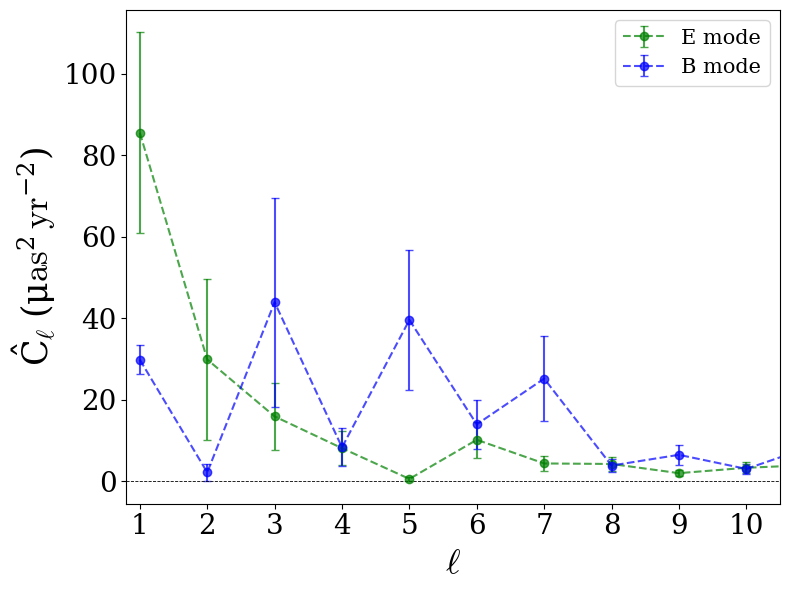

Auto QSO PM x QSO PM:
  E mode: chi2/dof = 53.24/10  p = 0.0000  (5.40 sigma)
  B mode: chi2/dof = 114.13/10  p = 0.0000  (inf sigma)


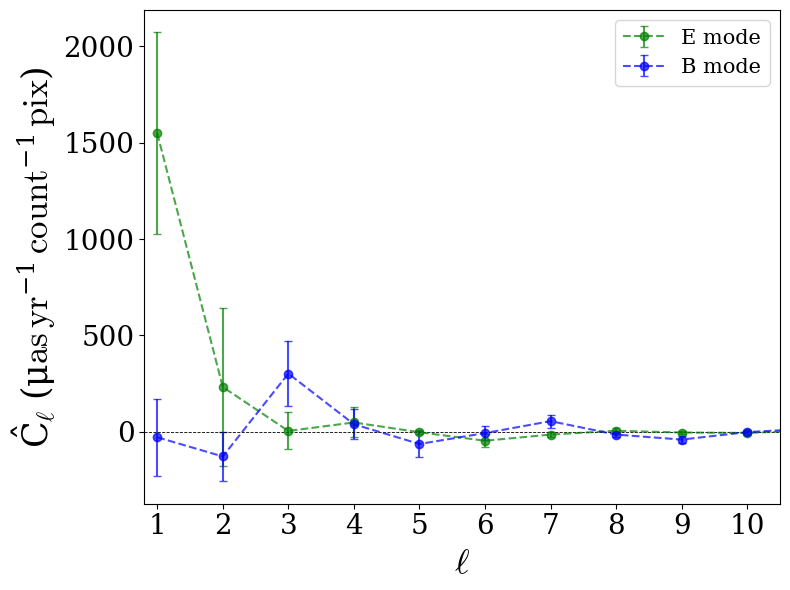

QSO PM x stellar density:
  E mode: chi2/dof = 12.81/10  p = 0.2343  (1.19 sigma)
  B mode: chi2/dof = 13.88/10  p = 0.1787  (1.34 sigma)


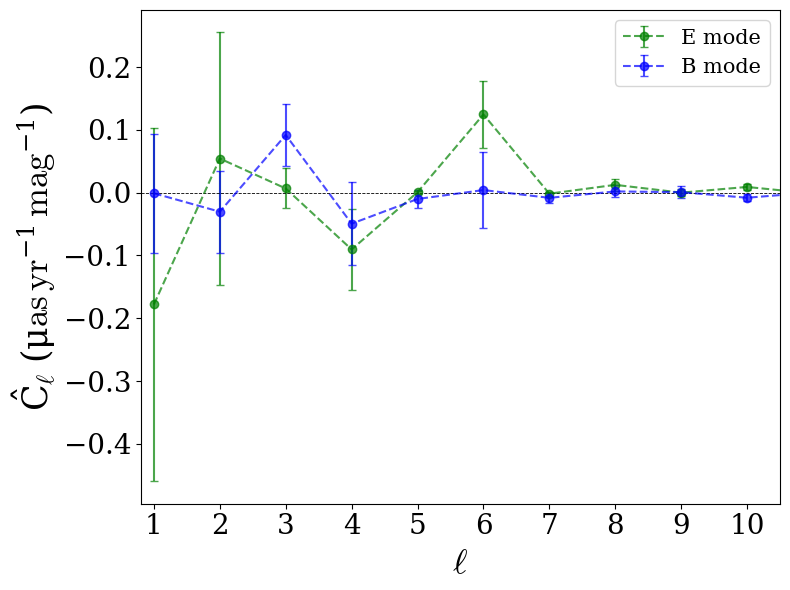

QSO PM x m10:
  E mode: chi2/dof = 12.82/10  p = 0.2341  (1.19 sigma)
  B mode: chi2/dof = 7.98/10  p = 0.6309  (0.48 sigma)


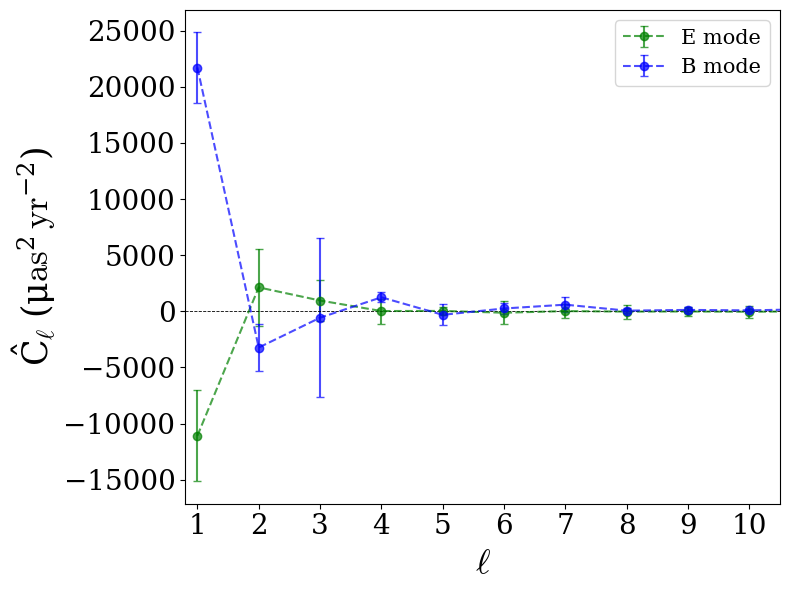

QSO PM x stellar PM:
  E mode: chi2/dof = 8.18/10  p = 0.6117  (0.51 sigma)
  B mode: chi2/dof = 59.82/10  p = 0.0000  (5.89 sigma)


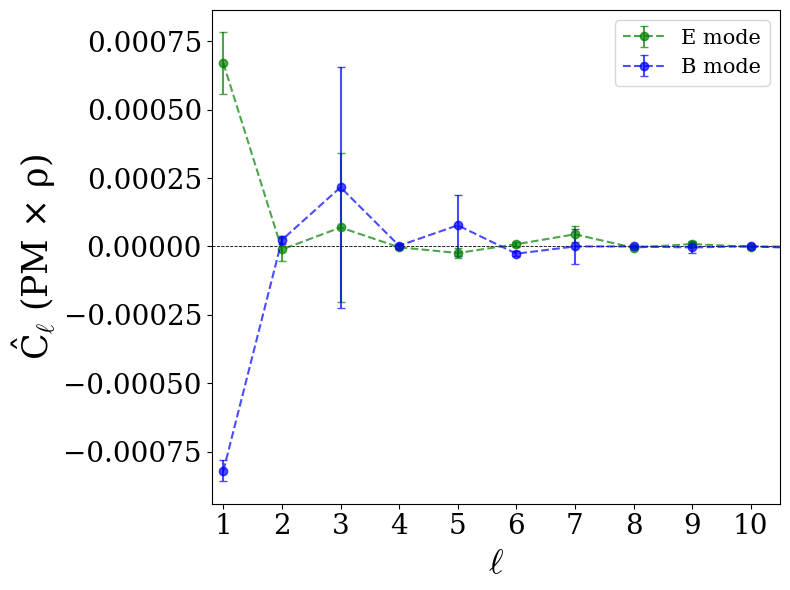

QSO PM x pm_corr:
  E mode: chi2/dof = 45.34/10  p = 0.0000  (4.77 sigma)
  B mode: chi2/dof = 475.26/10  p = 0.0000  (inf sigma)


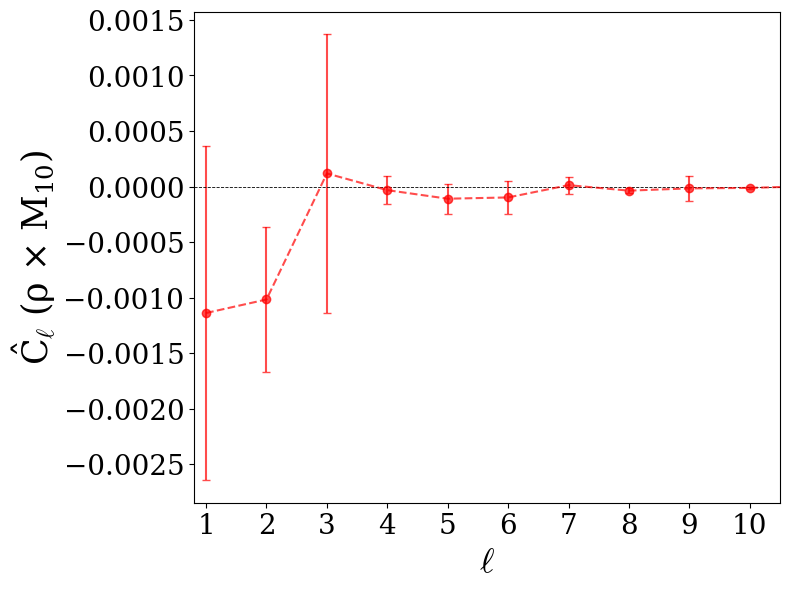

pm_corr x m10:
  TT: chi2/dof = 8.76/10  p = 0.5548  (0.59 sigma)


In [66]:
from scipy import stats as _stats
from scipy.special import erfinv as _erfinv

ell_mask_d1 = (ells_d1 >= 1) & (ells_d1 <= lmax_nmt)

def plot_d1(CL_E, CL_B, ERR_E, ERR_B, ylabel, fname):
    plt.figure(figsize=(8, 6))
    plt.errorbar(ells_d1[ell_mask_d1], CL_E[ell_mask_d1], yerr=ERR_E[ell_mask_d1],
                 fmt='go--', capsize=3, label='E mode', alpha=0.7)
    plt.errorbar(ells_d1[ell_mask_d1], CL_B[ell_mask_d1], yerr=ERR_B[ell_mask_d1],
                 fmt='bo--', capsize=3, label='B mode', alpha=0.7)
    plt.axhline(0, color='k', linewidth=0.6, linestyle='--')
    plt.xlabel(r'$\rm \ell$', fontsize=25)
    plt.ylabel(ylabel, fontsize=25)
    plt.legend(fontsize=15)
    plt.xlim(0.8, 10.5)
    plt.xticks(np.arange(1, 11, 1), fontsize=20)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    #plt.savefig(f'output/{fname}_{dataset}.pdf')
    plt.show()

def significance_d1(CL, ERR, label):
    mask10 = (ells_d1 >= 1) & (ells_d1 <= 10)
    chi2 = np.sum((CL[mask10] / ERR[mask10])**2)
    dof  = mask10.sum()
    p    = _stats.chi2.sf(chi2, dof)
    nsig = np.sqrt(2) * _erfinv(1 - p)
    print(f'  {label}: chi2/dof = {chi2:.2f}/{dof}  p = {p:.4f}  ({nsig:.2f} sigma)')

# ── Plot 1: Auto QSO PM ───────────────────────────────────────────────────────
plot_d1(CL_d1_auto_EE * 1e6, CL_d1_auto_BB * 1e6,
        ERR_d1_auto_EE * 1e6, ERR_d1_auto_BB * 1e6,
        r'$\hat{C}_{\rm  \ell} \, \, (\mu\mathrm{as}^2\,\mathrm{yr}^{-2})$',
        'cl_d1_qpm_auto')
print('Auto QSO PM x QSO PM:')
significance_d1(CL_d1_auto_EE, ERR_d1_auto_EE, 'E mode')
significance_d1(CL_d1_auto_BB, ERR_d1_auto_BB, 'B mode')

# ── Plot 2: Cross QSO PM x stellar density ────────────────────────────────────
plot_d1(CL_d1_sdens_E * 1e3, CL_d1_sdens_B * 1e3,
        ERR_d1_sdens_E * 1e3, ERR_d1_sdens_B * 1e3,
        r'$\hat{C}_{\rm  \ell} \, \,(\mu\mathrm{as}\,\mathrm{yr}^{-1} \, \mathrm{count}^{-1} \, \mathrm{pix})$',
        'cl_d1_qpm_x_sdens')
print('QSO PM x stellar density:')
significance_d1(CL_d1_sdens_E, ERR_d1_sdens_E, 'E mode')
significance_d1(CL_d1_sdens_B, ERR_d1_sdens_B, 'B mode')

# ── Plot 3: Cross QSO PM x m10 ────────────────────────────────────────────────
plot_d1(CL_d1_m10_E * 1e3, CL_d1_m10_B * 1e3,
        ERR_d1_m10_E * 1e3, ERR_d1_m10_B * 1e3,
        r'$\hat{C}_{\rm  \ell} \, \, (\mu\mathrm{as}\,\mathrm{yr}^{-1}\,\mathrm{mag}^{-1})$',
        'cl_d1_qpm_x_m10')
print('QSO PM x m10:')
significance_d1(CL_d1_m10_E, ERR_d1_m10_E, 'E mode')
significance_d1(CL_d1_m10_B, ERR_d1_m10_B, 'B mode')

# ── Plot 4: Cross QSO PM x stellar PM ────────────────────────────────────────
plot_d1(CL_d1_spm_EE * 1e6, CL_d1_spm_BB * 1e6,
        ERR_d1_spm_EE * 1e6, ERR_d1_spm_BB * 1e6,
        r'$\hat{C}_{\rm  \ell} \, \, (\mu\mathrm{as}^2\,\mathrm{yr}^{-2})$',
        'cl_d1_qpm_x_spm')
print('QSO PM x stellar PM:')
significance_d1(CL_d1_spm_EE, ERR_d1_spm_EE, 'E mode')
significance_d1(CL_d1_spm_BB, ERR_d1_spm_BB, 'B mode')

# ── Plot 5: Cross QSO PM x pm_corr ───────────────────────────────────────────
plot_d1(CL_d1_pmcorr_E, CL_d1_pmcorr_B,
        ERR_d1_pmcorr_E, ERR_d1_pmcorr_B,
        r'$\hat{C}_{\rm  \ell}$ (PM $\times$ $\rho$)',
        'cl_d1_qpm_x_corr')
print('QSO PM x pm_corr:')
significance_d1(CL_d1_pmcorr_E, ERR_d1_pmcorr_E, 'E mode')
significance_d1(CL_d1_pmcorr_B, ERR_d1_pmcorr_B, 'B mode')

# ── Plot 6: Cross pm_corr x m10  (spin-0 x spin-0, scalar) ───────────────────
def plot_d1_scalar(CL, ERR, ylabel, fname):
    plt.figure(figsize=(8, 6))
    plt.errorbar(ells_d1[ell_mask_d1], CL[ell_mask_d1], yerr=ERR[ell_mask_d1],
                 fmt='ro--', capsize=3, alpha=0.7)
    plt.axhline(0, color='k', linewidth=0.6, linestyle='--')
    plt.xlabel(r'$\rm \ell$', fontsize=25)
    plt.ylabel(ylabel, fontsize=25)
    plt.xlim(0.8, 10.5)
    plt.xticks(np.arange(1, 11, 1), fontsize=20)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    #plt.savefig(f'output/{fname}_{dataset}.pdf')
    plt.show()

def significance_d1_scalar(CL, ERR, label):
    mask10 = (ells_d1 >= 1) & (ells_d1 <= 10)
    chi2 = np.sum((CL[mask10] / ERR[mask10])**2)
    dof  = mask10.sum()
    p    = _stats.chi2.sf(chi2, dof)
    nsig = np.sqrt(2) * _erfinv(1 - p)
    print(f'  {label}: chi2/dof = {chi2:.2f}/{dof}  p = {p:.4f}  ({nsig:.2f} sigma)')

plot_d1_scalar(CL_d1_corrm10, ERR_d1_corrm10,
               r'$\hat{C}_{\rm  \ell}$ ($\rho$ $\times$ $M_{10}$)',
               'cl_d1_corr_x_m10')
print('pm_corr x m10:')
significance_d1_scalar(CL_d1_corrm10, ERR_d1_corrm10, 'TT')


## 3×4 panel: all cross-spectra across all datasets

Rows: QSO PM × stellar density | QSO PM × stellar PM | QSO PM × m10  
Columns: Gaia (no cut) | Gaia |b|>20° | Gaia |b|>30° | Quaia


── gaia (galcut=0°, quaia=False) ──
   f_sky = 0.879


/tmp/ipykernel_298638/2877070410.py:15: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  weighted_mean = np.divide(sum_weighted_data, sum_weights, where=sum_weights != 0)


   Computing coupling matrices...
   Running 500 MC sims...


/tmp/ipykernel_298638/1394781643.py:106: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  sim_sd_raw  = hp.synfast(fid_sdens_ds, nside, lmax=lmax_nmt, verbose=False)
/tmp/ipykernel_298638/1394781643.py:107: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  sim_m10_raw = hp.synfast(fid_m10_ds,   nside, lmax=lmax_nmt, verbose=False)


     100/500
     200/500
     300/500
     400/500
     500/500
   gaia done.

── gaia_galcut_20 (galcut=20°, quaia=False) ──
   f_sky = 0.658
   Computing coupling matrices...
   Running 500 MC sims...
     100/500
     200/500
     300/500
     400/500
     500/500
   gaia_galcut_20 done.

── gaia_galcut_30 (galcut=30°, quaia=False) ──
   f_sky = 0.500
   Computing coupling matrices...
   Running 500 MC sims...
     100/500
     200/500
     300/500
     400/500
     500/500
   gaia_galcut_30 done.

── quaia (galcut=0°, quaia=True) ──


/tmp/ipykernel_298638/2877070410.py:15: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  weighted_mean = np.divide(sum_weighted_data, sum_weights, where=sum_weights != 0)


   f_sky = 0.842
   Computing coupling matrices...
   Running 500 MC sims...


/tmp/ipykernel_298638/1394781643.py:106: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  sim_sd_raw  = hp.synfast(fid_sdens_ds, nside, lmax=lmax_nmt, verbose=False)
/tmp/ipykernel_298638/1394781643.py:107: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  sim_m10_raw = hp.synfast(fid_m10_ds,   nside, lmax=lmax_nmt, verbose=False)


     100/500
     200/500
     300/500
     400/500
     500/500
   quaia done.

All datasets complete.


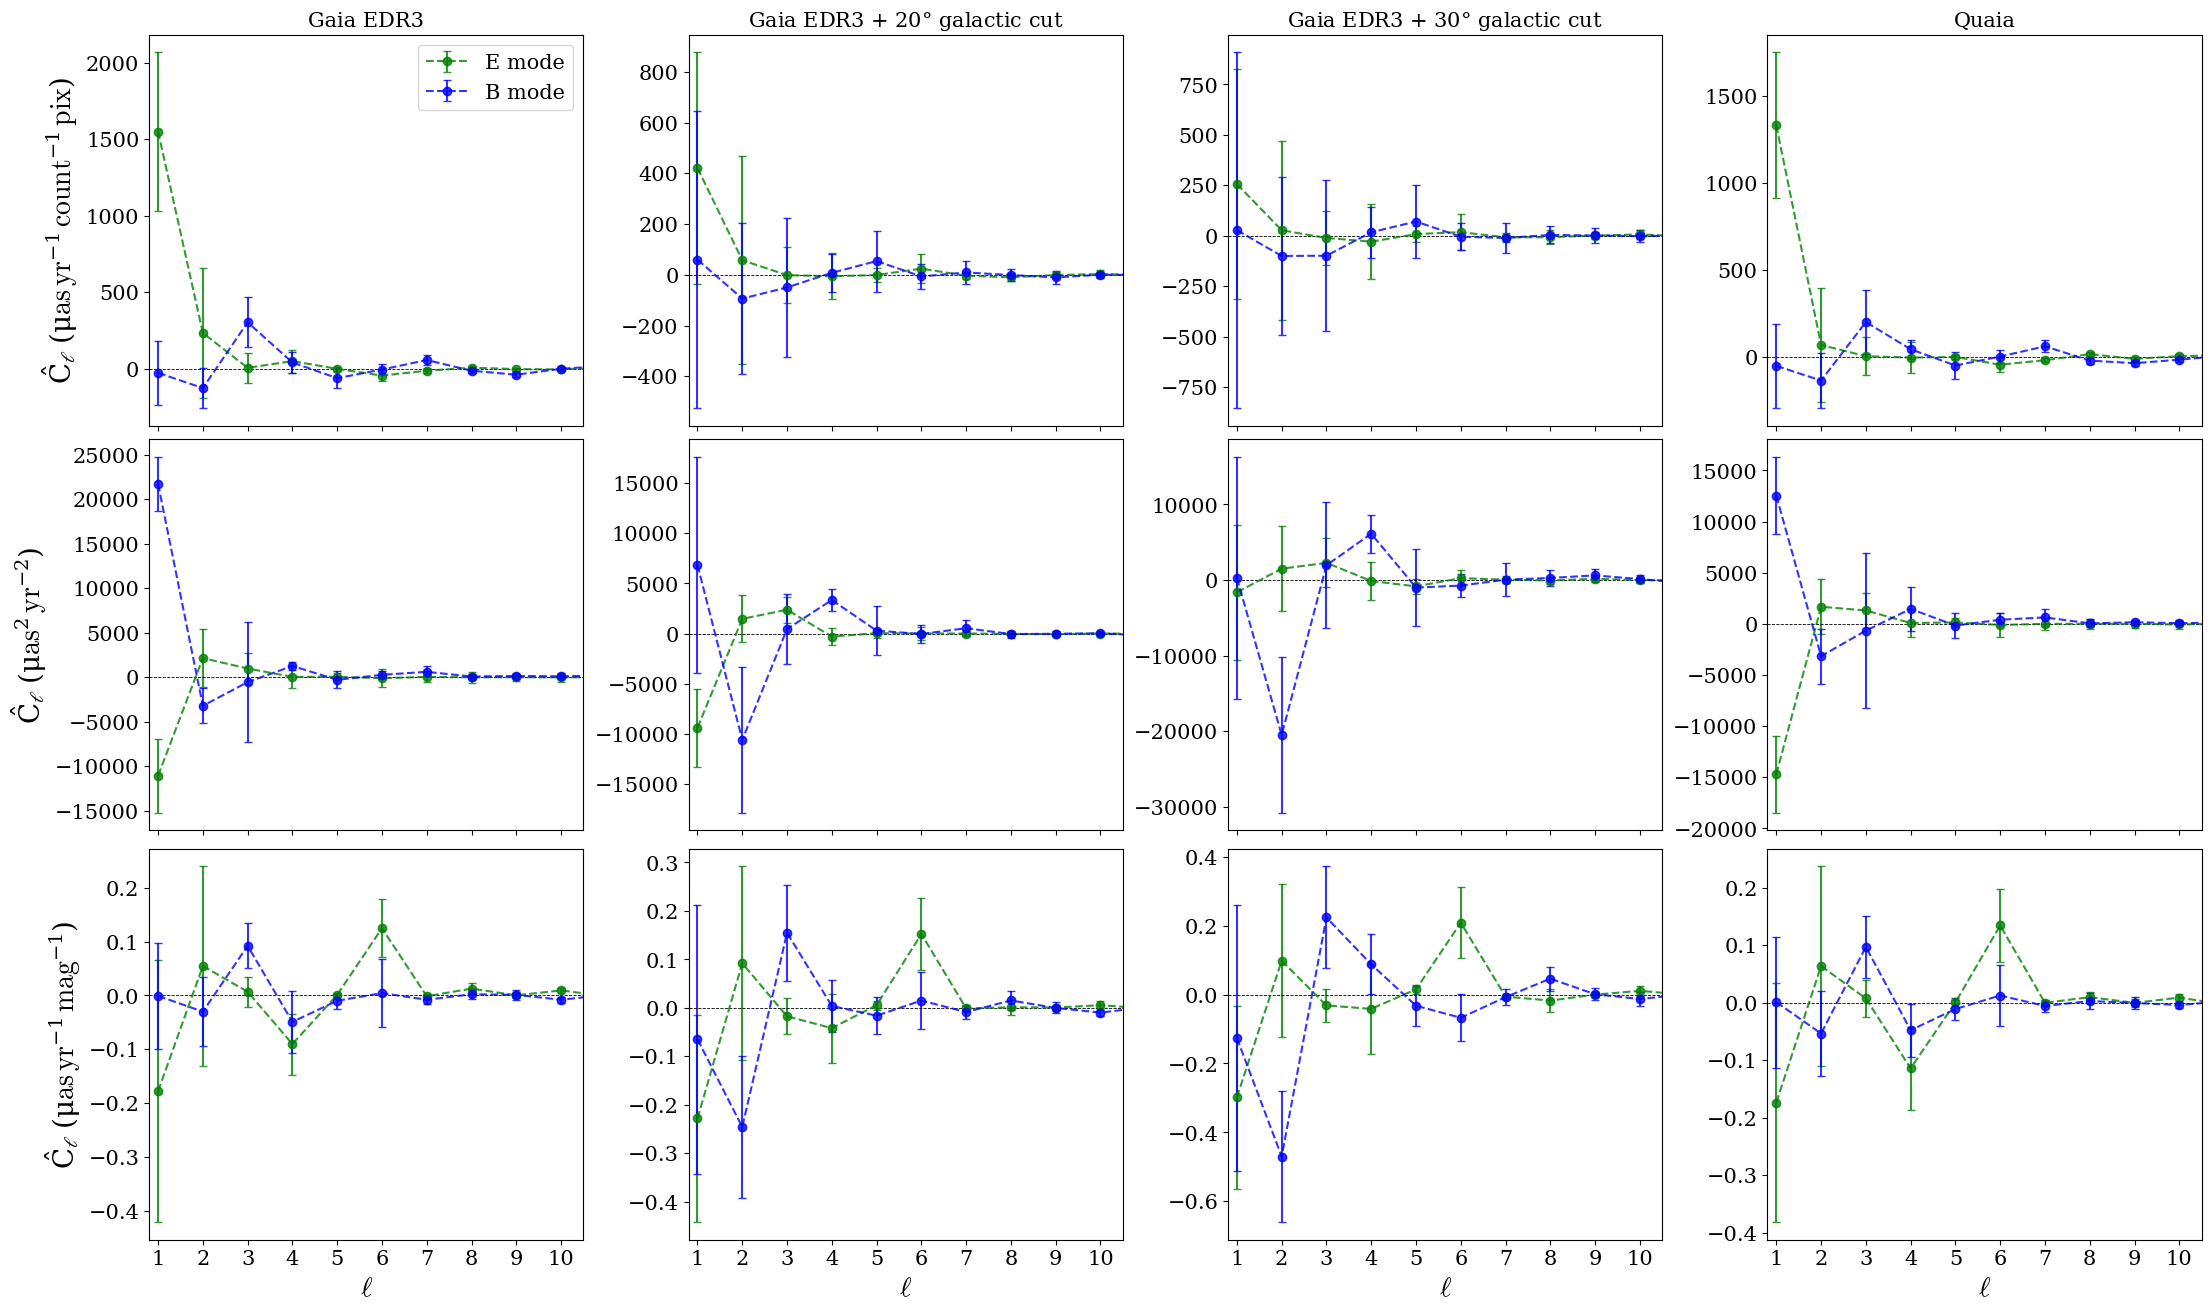

Saved output/cross_spectra_panel.pdf


In [ ]:
# ── 3×4 panel: all cross-spectra across all 4 datasets ─────────────────────
import astropy.table as at

# Datasets: (label, galactic_cut_deg, use_quaia_filter)
DATASETS = [
    ('gaia',          0,   False),
    ('gaia_galcut_20', 20,  False),
    ('gaia_galcut_30', 30,  False),
    ('quaia',         0,  True),
]

panel_results = {}   # label -> dict of CL/ERR arrays

for (label, galcut, use_quaia) in DATASETS:
    print(f'\n── {label} (galcut={galcut}°, quaia={use_quaia}) ──')

    # 1. Galactic mask for this dataset
    mask_galactic_ds = np.abs(galactic_coords.b.deg) > galcut

    # 2. QSO catalog for this dataset
    if use_quaia:
        table_quaia = at.Table.read('quaia_G20.0.fits')
        gaia_ds = gaia[gaia['source_id'].isin(table_quaia['source_id'])].reset_index(drop=True)
    else:
        gaia_ds = gaia

    # 3. Rebuild QSO PM weighted-mean maps
    gaia_theta_ds = np.radians(90 - gaia_ds['dec'].values)
    gaia_phi_ds   = np.radians(gaia_ds['ra'].values)
    pmra_wm_ds  = pixelize.calculate_weighted_means(
        gaia_theta_ds, gaia_phi_ds,
        gaia_ds['pmra'].values, gaia_ds['pmra_error'].values)
    pmdec_wm_ds = pixelize.calculate_weighted_means(
        gaia_theta_ds, gaia_phi_ds,
        gaia_ds['pmdec'].values, gaia_ds['pmdec_error'].values)

    # 4. Masks
    mask_gaia_ds  = (pmra_wm_ds != 0) & (pmdec_wm_ds != 0) & mask_galactic_ds
    mask_cross_ds = mask_gaia_ds & mask_sdens & mask_m10
    mask_all_ds   = (mask_gaia_ds & mask_star_pm & mask_cross_ds).astype(float)
    print(f'   f_sky = {mask_all_ds.mean():.3f}')

    # 5. Mean-subtract scalar maps within new mask
    sum_mask  = np.sum(mask_cross_ds)
    mean_sdens_ds = np.sum(nstar_per_pixel * mask_cross_ds) / sum_mask
    mean_m10_ds   = np.sum(m10_map         * mask_cross_ds) / sum_mask
    nstar_ms_ds   = np.where(mask_cross_ds, nstar_per_pixel - mean_sdens_ds, 0.0)
    m10_ms_ds     = np.where(mask_cross_ds, m10_map         - mean_m10_ds,   0.0)

    # 6. NaMaster fields (no apodization, spin-1 no purify)
    f_qpm_ds   = nmt.NmtField(mask_all_ds, [-pmdec_wm_ds,    pmra_wm_ds],    spin=1)
    f_sdens_ds = nmt.NmtField(mask_all_ds, [nstar_ms_ds])
    f_m10_ds   = nmt.NmtField(mask_all_ds, [m10_ms_ds])
    f_spm_ds   = nmt.NmtField(mask_all_ds, [-star_pmdec_wm,  star_pmra_wm],  spin=1)

    # 7. Workspaces + auto-spectra for fiducials
    print('   Computing coupling matrices...')
    ws_auto_ds  = nmt.NmtWorkspace(); ws_auto_ds.compute_coupling_matrix(f_qpm_ds, f_qpm_ds,   bins_d1)
    ws_sdens_ds = nmt.NmtWorkspace(); ws_sdens_ds.compute_coupling_matrix(f_qpm_ds, f_sdens_ds, bins_d1)
    ws_m10_ds   = nmt.NmtWorkspace(); ws_m10_ds.compute_coupling_matrix(f_qpm_ds,   f_m10_ds,   bins_d1)
    ws_spm_ds   = nmt.NmtWorkspace(); ws_spm_ds.compute_coupling_matrix(f_qpm_ds,   f_spm_ds,   bins_d1)
    ws_spm_auto_ds = nmt.NmtWorkspace(); ws_spm_auto_ds.compute_coupling_matrix(f_spm_ds, f_spm_ds, bins_d1)

    def dc_ds(ws, f1, f2):
        return ws.decouple_cell(nmt.compute_coupled_cell(f1, f2))

    # 8. Data Cl
    cl_auto_ds      = dc_ds(ws_auto_ds,     f_qpm_ds, f_qpm_ds)
    cl_sdens_ds     = dc_ds(ws_sdens_ds,    f_qpm_ds, f_sdens_ds)
    cl_m10_ds       = dc_ds(ws_m10_ds,      f_qpm_ds, f_m10_ds)
    cl_spm_ds       = dc_ds(ws_spm_ds,      f_qpm_ds, f_spm_ds)
    cl_spm_auto_ds  = dc_ds(ws_spm_auto_ds, f_spm_ds, f_spm_ds)

    # 9. Fiducials for MC (use ells_d1[1:] to skip ell=0 placeholder)
    fid_qpm_EE_ds  = bandpower_to_full_cl(ells_d1[1:], cl_auto_ds[0][1:],       lmax_nmt)
    fid_qpm_BB_ds  = bandpower_to_full_cl(ells_d1[1:], cl_auto_ds[3][1:],       lmax_nmt)
    fid_spm_EE_ds  = bandpower_to_full_cl(ells_d1[1:], cl_spm_auto_ds[0][1:],   lmax_nmt)
    fid_spm_BB_ds  = bandpower_to_full_cl(ells_d1[1:], cl_spm_auto_ds[3][1:],   lmax_nmt)
    fid_sdens_ds   = bandpower_to_full_cl(ells[ells <= lmax_nmt], cl_sdens_auto[ells <= lmax_nmt], lmax_nmt)
    fid_m10_ds     = bandpower_to_full_cl(ells[ells <= lmax_nmt], cl_m10_auto  [ells <= lmax_nmt], lmax_nmt)

    # 10. MC simulations for error bars
    n_ells_d1 = len(ells_d1)
    sims_sdens_E_ds = np.zeros((N_SIMS, n_ells_d1))
    sims_sdens_B_ds = np.zeros((N_SIMS, n_ells_d1))
    sims_m10_E_ds   = np.zeros((N_SIMS, n_ells_d1))
    sims_m10_B_ds   = np.zeros((N_SIMS, n_ells_d1))
    sims_spm_EE_ds  = np.zeros((N_SIMS, n_ells_d1))
    sims_spm_BB_ds  = np.zeros((N_SIMS, n_ells_d1))

    print(f'   Running {N_SIMS} MC sims...')
    for j in range(N_SIMS):
        # QSO PM (spin-1)
        alm_E_q = hp.synalm(fid_qpm_EE_ds, lmax=lmax_nmt)
        alm_B_q = hp.synalm(fid_qpm_BB_ds, lmax=lmax_nmt)
        mth_q, mph_q = hp.alm2map_spin([alm_E_q, alm_B_q], nside, spin=1, lmax=lmax_nmt)
        sim_pmra_q = mph_q;  sim_pmdec_q = -mth_q

        # Stellar PM (spin-1, independent)
        alm_E_s = hp.synalm(fid_spm_EE_ds, lmax=lmax_nmt)
        alm_B_s = hp.synalm(fid_spm_BB_ds, lmax=lmax_nmt)
        mth_s, mph_s = hp.alm2map_spin([alm_E_s, alm_B_s], nside, spin=1, lmax=lmax_nmt)
        sim_pmra_s = mph_s;  sim_pmdec_s = -mth_s

        # Scalar fields (mean-subtract within mask)
        sim_sd_raw  = hp.synfast(fid_sdens_ds, nside, lmax=lmax_nmt, verbose=False)
        sim_m10_raw = hp.synfast(fid_m10_ds,   nside, lmax=lmax_nmt, verbose=False)
        sim_sd_ms   = sim_sd_raw  - np.sum(sim_sd_raw  * mask_all_ds) / np.sum(mask_all_ds)
        sim_m10_ms2 = sim_m10_raw - np.sum(sim_m10_raw * mask_all_ds) / np.sum(mask_all_ds)

        f_q_j   = nmt.NmtField(mask_all_ds, [-sim_pmdec_q, sim_pmra_q], spin=1)
        f_s_j   = nmt.NmtField(mask_all_ds, [-sim_pmdec_s, sim_pmra_s], spin=1)
        f_sd_j  = nmt.NmtField(mask_all_ds, [sim_sd_ms])
        f_m10_j = nmt.NmtField(mask_all_ds, [sim_m10_ms2])

        cl_sd_j  = ws_sdens_ds.decouple_cell(nmt.compute_coupled_cell(f_q_j, f_sd_j))
        cl_m10_j = ws_m10_ds.decouple_cell(nmt.compute_coupled_cell(f_q_j, f_m10_j))
        cl_spm_j = ws_spm_ds.decouple_cell(nmt.compute_coupled_cell(f_q_j, f_s_j))

        sims_sdens_E_ds[j] = cl_sd_j[0];   sims_sdens_B_ds[j] = cl_sd_j[1]
        sims_m10_E_ds[j]   = cl_m10_j[0];  sims_m10_B_ds[j]   = cl_m10_j[1]
        sims_spm_EE_ds[j]  = cl_spm_j[0];  sims_spm_BB_ds[j]  = cl_spm_j[3]

        if (j + 1) % 100 == 0:
            print(f'     {j+1}/{N_SIMS}')

    panel_results[label] = {
        'CL_sdens_E':  cl_sdens_ds[0],  'CL_sdens_B':  cl_sdens_ds[1],
        'ERR_sdens_E': np.std(sims_sdens_E_ds, axis=0),
        'ERR_sdens_B': np.std(sims_sdens_B_ds, axis=0),
        'CL_m10_E':    cl_m10_ds[0],    'CL_m10_B':    cl_m10_ds[1],
        'ERR_m10_E':   np.std(sims_m10_E_ds, axis=0),
        'ERR_m10_B':   np.std(sims_m10_B_ds, axis=0),
        'CL_spm_EE':   cl_spm_ds[0],    'CL_spm_BB':   cl_spm_ds[3],
        'ERR_spm_EE':  np.std(sims_spm_EE_ds, axis=0),
        'ERR_spm_BB':  np.std(sims_spm_BB_ds, axis=0),
    }
    print(f'   {label} done.')

print('\nAll datasets complete.')

# ── 3×4 Panel plot ────────────────────────────────────────────────────────────
col_labels = [
    'Gaia EDR3',
    r'Gaia EDR3 + $20°$ galactic cut',
    r'Gaia EDR3 + $30°$ galactic cut',
    'Quaia',
]
row_specs = [
    # (key_prefix, ylabel, scale)
    ('sdens', r'$\hat{C}_\ell \;(\mu\mathrm{as}\,\mathrm{yr}^{-1}\,\mathrm{count}^{-1}\,\mathrm{pix})$', 1e3),
    ('spm',   r'$\hat{C}_\ell \;(\mu\mathrm{as}^2\,\mathrm{yr}^{-2})$',                                  1e6),
    ('m10',   r'$\hat{C}_\ell \;(\mu\mathrm{as}\,\mathrm{yr}^{-1}\,\mathrm{mag}^{-1})$',                 1e3),
]
ds_labels = ['gaia', 'gaia_galcut_20', 'gaia_galcut_30', 'quaia']

fig, axes = plt.subplots(3, 4, figsize=(22, 13), constrained_layout=True, sharex=True)

for row, (key, ylabel, scale) in enumerate(row_specs):
    for col, lbl in enumerate(ds_labels):
        ax = axes[row, col]
        r  = panel_results[lbl]

        if key == 'spm':
            CL_E  = r['CL_spm_EE'];  CL_B  = r['CL_spm_BB']
            ERR_E = r['ERR_spm_EE']; ERR_B = r['ERR_spm_BB']
            e_lab, b_lab = 'EE', 'BB'
        else:
            CL_E  = r[f'CL_{key}_E'];  CL_B  = r[f'CL_{key}_B']
            ERR_E = r[f'ERR_{key}_E']; ERR_B = r[f'ERR_{key}_B']
            e_lab, b_lab = 'E mode', 'B mode'

        ax.errorbar(ells_d1[ell_mask_d1],
                    CL_E[ell_mask_d1] * scale,
                    yerr=ERR_E[ell_mask_d1] * scale,
                    fmt='go--', capsize=3, label=e_lab, alpha=0.8)
        ax.errorbar(ells_d1[ell_mask_d1],
                    CL_B[ell_mask_d1] * scale,
                    yerr=ERR_B[ell_mask_d1] * scale,
                    fmt='bo--', capsize=3, label=b_lab, alpha=0.8)
        ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
        ax.set_xlim(0.8, 10.5)
        ax.set_xticks(range(1, 11))
        ax.tick_params(labelsize=15)

        if row == 0:
            ax.set_title(col_labels[col], fontsize=15)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=20)
        if row == 2:
            ax.set_xlabel(r'$\rm \ell$', fontsize=20)
        if row == 0 and col == 0:
            ax.legend(fontsize=15)

import os
os.makedirs('output', exist_ok=True)
plt.savefig('output/cross_spectra_panel.pdf', bbox_inches='tight')
plt.show()
print('Saved output/cross_spectra_panel.pdf')
